In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, json, re, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from collections import defaultdict

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Replace your CFG block — only 4 numbers change
# Replace your CFG — model size back to V3.3, keep prev_yield feature
CFG = {
    'hidden_dim'   : 128,    # ← back from 192
    'embed_dim'    : 32,     # ← back from 48
    'n_features'   : 9,
    'max_days'     : 186,
    'lr'           : 1e-3,   # ← back from 8e-4
    'weight_decay' : 1e-5,
    'epochs'       : 100,    # ← back from 120
    'batch_size'   : 64,
    'dropout'      : 0.2,
    'seed'         : 42,
    'n_heads'      : 4,      # ← back from 6
    'n_enc_layers' : 3,      # ← back from 4
    'patch_size'   : 7,
    'graph_window' : 3,
    'ffn_dim'      : 256,    # ← back from 384
}

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])

HRRR_VARS = [
    'Avg Temperature (K)', 'Max Temperature (K)', 'Min Temperature (K)',
    'Precipitation (kg m**-2)', 'Relative Humidity (%)',
    'U Component of Wind (m s**-1)', 'V Component of Wind (m s**-1)',
    'Downward Shortwave Radiation Flux (W m**-2)', 'Vapor Pressure Deficit (kPa)',
]

STATE_MAP = {'17': 0, '19': 1, '27': 2, '38': 3, '37': 4}  # IL IA MN ND NC
N_DERIVED = 14   # 9 raw + 5 derived (used in Cell 4)

print('Config ready.')

Device: cuda
Config ready.


In [ ]:
LOCAL_HRRR = '/content/data/hrrr'
LOCAL_USDA = '/content/data/usda'
DRIVE_HRRR = '/content/drive/MyDrive/CropNet/WRF-HRRR Computed Dataset/data'
DRIVE_USDA = '/content/drive/MyDrive/CropNet/USDA Crop Dataset/data/Soybeans'

hrrr_root = LOCAL_HRRR if (os.path.exists(LOCAL_HRRR) and
    sum(len(f) for _,_,f in os.walk(LOCAL_HRRR)) > 0) else DRIVE_HRRR
usda_root = LOCAL_USDA if (os.path.exists(LOCAL_USDA) and
    sum(len(f) for _,_,f in os.walk(LOCAL_USDA)) > 0) else DRIVE_USDA

hrrr_re = re.compile(r'HRRR_(\d+)_([A-Z]{2})_(\d{4})-(\d{2})\.csv$')
usda_re = re.compile(r'USDA_Soybean_County_(\d{4})\.csv$', re.IGNORECASE)

HRRR_FILE_MAP = {}
for root, dirs, files in os.walk(hrrr_root):
    for fname in files:
        if hrrr_re.search(fname):
            HRRR_FILE_MAP[fname] = os.path.join(root, fname)
print(f'HRRR files indexed: {len(HRRR_FILE_MAP)}')

USDA_YEAR_MAP = {}
for root, dirs, files in os.walk(usda_root):
    for fname in files:
        m = usda_re.search(fname)
        if m:
            USDA_YEAR_MAP[int(m.group(1))] = os.path.join(root, fname)
print(f'USDA files indexed: {len(USDA_YEAR_MAP)}')

_HRRR_CACHE, _USDA_CACHE = {}, {}

def _find_col_robust(df, candidates):
    for c in candidates:
        if c in df.columns: return c
    for c in candidates:
        for col in df.columns:
            if c.lower().replace(' ','_') == col.lower().replace(' ','_'):
                return col
    return None

def get_hrrr_cached_df(original_path):
    fname = os.path.basename(original_path)
    real_path = HRRR_FILE_MAP.get(fname)
    if real_path is None: return None
    if real_path not in _HRRR_CACHE:
        try:
            df = pd.read_csv(real_path,
                             usecols=['FIPS Code', 'Day'] + HRRR_VARS,
                             dtype={'FIPS Code': str})
            df['FIPS Code'] = (df['FIPS Code'].str.strip()
                               .str.replace(r'\.0$', '', regex=True).str.zfill(5))
            _HRRR_CACHE[real_path] = df
        except Exception as e:
            _HRRR_CACHE[real_path] = None
    return _HRRR_CACHE[real_path]

def get_usda_cached_df(year):
    path = USDA_YEAR_MAP.get(int(year))
    if path is None: return None
    if path not in _USDA_CACHE:
        try:
            df = pd.read_csv(path, dtype=str)
            df.columns = df.columns.str.strip()
            _USDA_CACHE[path] = df
        except:
            _USDA_CACHE[path] = None
    return _USDA_CACHE[path]

def load_hrrr_month(original_path, fips_code):
    df = get_hrrr_cached_df(original_path)
    if df is None: return None
    fips_str = str(fips_code).strip().replace('.0','').zfill(5)
    county_df = df[df['FIPS Code'] == fips_str]
    if county_df.empty: return None
    daily = county_df.groupby('Day')[HRRR_VARS].mean().sort_index()
    arr = daily.values.astype(np.float32)
    col_means = np.nanmean(arr, axis=0)
    for j in range(arr.shape[1]):
        arr[np.isnan(arr[:, j]), j] = col_means[j]
    return arr

def load_short_term(paths, fips_code, max_days=186):
    chunks = [a for p in paths
              for a in [load_hrrr_month(p, fips_code)] if a is not None]
    arr = (np.concatenate(chunks, axis=0) if chunks
           else np.zeros((max_days, len(HRRR_VARS)), dtype=np.float32))
    if arr.shape[0] < max_days:
        arr = np.vstack([arr, np.zeros(
            (max_days - arr.shape[0], len(HRRR_VARS)), np.float32)])
    return arr[:max_days].T   # (9, max_days)

def load_long_term(paths_list, fips_code):
    years_out = []
    for yr_paths in paths_list:
        monthly = []
        for p in yr_paths:
            a = load_hrrr_month(p, fips_code)
            monthly.append(a.mean(0) if a is not None
                           else np.zeros(len(HRRR_VARS), dtype=np.float32))
        while len(monthly) < 12:
            monthly.append(np.zeros(len(HRRR_VARS), dtype=np.float32))
        years_out.append(np.stack(monthly[:12], axis=0))
    while len(years_out) < 3:
        years_out.append(np.zeros((12, len(HRRR_VARS)), dtype=np.float32))
    return np.stack(years_out[:3], axis=0)   # (3, 12, 9)

def get_usda_yield(state_ansi, county_ansi, year):
    df = get_usda_cached_df(year)
    if df is None: return None
    s_col = _find_col_robust(df, ['state_ansi','State ANSI','STATE_ANSI'])
    c_col = _find_col_robust(df, ['county_ansi','County ANSI','COUNTY_ANSI'])
    y_col = _find_col_robust(df, ['YIELD, MEASURED IN BU / ACRE',
                  'YIELD, MEASURED IN BU/ACRE','Value','YIELD','Data Value'])
    if not all([s_col, c_col, y_col]): return None
    mask = ((df[s_col].str.strip().str.zfill(2) == str(state_ansi).zfill(2)) &
            (df[c_col].str.strip().str.zfill(3) == str(county_ansi).zfill(3)))
    rows = df[mask]
    if rows.empty: return None
    val = pd.to_numeric(
        rows[y_col].replace({'(D)': np.nan, '': np.nan, ' ': np.nan}).values[0],
        errors='coerce')
    return float(val) if pd.notna(val) else None

print('Data utilities ready.')

HRRR files indexed: 3456
USDA files indexed: 7
Data utilities ready.


In [ ]:
class SoybeanDataset(Dataset):
    def __init__(self, json_path):
        with open(json_path) as f: raw = json.load(f)
        self.records = []
        skipped, skipped_no_yield, skipped_no_state = 0, 0, 0
        print(f'Loading {len(raw)} records from {os.path.basename(json_path)}...')
        for rec in tqdm(raw, leave=False):
            yld = get_usda_yield(rec['state_ansi'], rec['county_ansi'], rec['year'])
            if yld is None:
                skipped_no_yield += 1; skipped += 1; continue
            st = load_short_term(rec['data']['HRRR']['short_term'],
                                 rec['FIPS'], CFG['max_days'])
            lt = load_long_term(rec['data']['HRRR']['long_term'], rec['FIPS'])
            if (st == 0).all() and (lt == 0).all():
                skipped += 1; continue
            s_idx = STATE_MAP.get(str(rec['state_ansi']).zfill(2), -1)
            if s_idx == -1:
                skipped_no_state += 1; skipped += 1; continue
            self.records.append({
                'short_term': torch.tensor(st, dtype=torch.float32),
                'long_term' : torch.tensor(lt, dtype=torch.float32),
                'yield'     : torch.tensor(yld, dtype=torch.float32),
                'state_idx' : torch.tensor(s_idx, dtype=torch.long),
                'fips'      : rec['FIPS'],
                'county'    : rec['county'],
                'state'     : rec['state'],
                'year'      : rec['year'],
            })
        print(f'  ✅ Loaded: {len(self.records)}  |  ⚠ Skipped: {skipped}')
        print(f'     - Missing yield: {skipped_no_yield} | Unknown state: {skipped_no_state}')

    def __len__(self): return len(self.records)
    def __getitem__(self, idx): return self.records[idx]


train_ds = SoybeanDataset('/content/soybean_train (4).json')
test_ds  = SoybeanDataset('/content/soybean_test (3).json')

# ── Normalization stats (global) ──────────────────────────────────────
all_y  = [r['yield'].item() for r in train_ds.records]
all_st = np.stack([r['short_term'].numpy() for r in train_ds.records])
all_lt = np.stack([r['long_term'].numpy()  for r in train_ds.records])

YIELD_MEAN = float(np.mean(all_y))
YIELD_STD  = float(np.std(all_y) + 1e-6)

ST_MEAN = torch.tensor(all_st.mean((0,2)), dtype=torch.float32).view(1,9,1).to(DEVICE)
ST_STD  = torch.tensor(all_st.std((0,2)) + 1e-6, dtype=torch.float32).view(1,9,1).to(DEVICE)
LT_MEAN = torch.tensor(all_lt.mean((0,1,2)), dtype=torch.float32).view(1,1,1,9).to(DEVICE)
LT_STD  = torch.tensor(all_lt.std((0,1,2)) + 1e-6, dtype=torch.float32).view(1,1,1,9).to(DEVICE)

print(f'Yield → mean={YIELD_MEAN:.2f}  std={YIELD_STD:.2f} bu/acre')
print(f'Stats from {len(train_ds)} training samples.')

Loading 1224 records from soybean_train (4).json...


  0%|          | 0/1224 [00:00<?, ?it/s]

  ✅ Loaded: 1039  |  ⚠ Skipped: 185
     - Missing yield: 185 | Unknown state: 0
Loading 408 records from soybean_test (3).json...


  0%|          | 0/408 [00:00<?, ?it/s]

  ✅ Loaded: 382  |  ⚠ Skipped: 26
     - Missing yield: 26 | Unknown state: 0
Yield → mean=47.54  std=13.09 bu/acre
Stats from 1039 training samples.


# old

### 3 a

In [ ]:
# ── Compute ST_MEAN / ST_STD from training data ───────────────────────
st_stack = torch.stack([r['short_term'] for r in train_ds.records])  # (N,9,T)
ST_MEAN  = st_stack.mean(dim=(0, 2), keepdim=True).to(DEVICE)        # (1,9,1)
ST_STD   = st_stack.std(dim=(0, 2),  keepdim=True).clamp(min=1e-6).to(DEVICE)

lt_stack = torch.stack([r['long_term'] for r in train_ds.records])   # (N,3,12,9)
LT_MEAN  = lt_stack.mean(dim=0, keepdim=True).to(DEVICE)             # (1,3,12,9)
LT_STD   = lt_stack.std(dim=0,  keepdim=True).clamp(min=1e-6).to(DEVICE)

YIELD_MEAN = float(torch.stack([r['yield'] for r in train_ds.records]).mean())
YIELD_STD  = float(torch.stack([r['yield'] for r in train_ds.records]).std())

print(f'ST_MEAN  shape : {ST_MEAN.shape}')
print(f'LT_MEAN  shape : {LT_MEAN.shape}')
print(f'Yield    mean  : {YIELD_MEAN:.2f}  std: {YIELD_STD:.2f}')
print('Weather stats computed ✅')

ST_MEAN  shape : torch.Size([1, 9, 1])
LT_MEAN  shape : torch.Size([1, 3, 12, 9])
Yield    mean  : 47.54  std: 13.10
Weather stats computed ✅


### 3 b

In [ ]:
# ── Per-state yield stats ─────────────────────────────────────────────
state_yields = defaultdict(list)
for r in train_ds.records:
    state_yields[r['state']].append(r['yield'].item())

STATE_YIELD_STATS = {
    s: (float(np.mean(v)), float(np.std(v) + 1e-6))
    for s, v in state_yields.items()
}
print('Per-state yield stats:')
for s, (m, sd) in sorted(STATE_YIELD_STATS.items()):
    print(f'  {s}: mean={m:.2f}  std={sd:.2f}  n={len(state_yields[s])}')

# ── County map ────────────────────────────────────────────────────────
all_fips = sorted(set(
    [r['fips'] for r in train_ds.records] +
    [r['fips'] for r in test_ds.records]))
COUNTY_MAP = {fips: idx for idx, fips in enumerate(all_fips)}
N_COUNTIES = len(COUNTY_MAP)
print(f'Counties indexed: {N_COUNTIES}')

# ── Year feature ──────────────────────────────────────────────────────
YEAR_MIN, YEAR_MAX = 2015, 2024
def year_to_feat(year):
    return float((int(year) - YEAR_MIN) / (YEAR_MAX - YEAR_MIN + 1e-6))

# ── County historical yield ───────────────────────────────────────────
county_yield_history = defaultdict(list)
for r in train_ds.records:
    county_yield_history[r['fips']].append(r['yield'].item())

COUNTY_YIELD_MEAN = {
    fips: float(np.mean(v)) for fips, v in county_yield_history.items()
}
GLOBAL_YIELD_MEAN = float(np.mean(list(COUNTY_YIELD_MEAN.values())))

# ── Previous year yield lookup ────────────────────────────────────────
yield_lookup = {}
for ds_ in [train_ds, test_ds]:
    for r in ds_.records:
        yield_lookup[(r['state'], r['fips'], int(r['year']))] = r['yield'].item()

# ── Inject all features ───────────────────────────────────────────────
missing_prev = 0
for ds_ in [train_ds, test_ds]:
    for r in ds_.records:
        s      = r['state']
        sm, ss = STATE_YIELD_STATS.get(s, (YIELD_MEAN, YIELD_STD))

        raw_hist = COUNTY_YIELD_MEAN.get(r['fips'], GLOBAL_YIELD_MEAN)
        r['county_hist_yield'] = torch.tensor((raw_hist - sm) / ss, dtype=torch.float32)

        prev_key = (s, r['fips'], int(r['year']) - 1)
        raw_prev = yield_lookup.get(prev_key, raw_hist)
        if prev_key not in yield_lookup:
            missing_prev += 1
        r['prev_yield']       = torch.tensor((raw_prev - sm) / ss, dtype=torch.float32)

        r['state_yield_mean'] = torch.tensor(sm, dtype=torch.float32)
        r['state_yield_std']  = torch.tensor(ss, dtype=torch.float32)
        r['year_feat']        = torch.tensor(year_to_feat(r['year']), dtype=torch.float32)
        r['county_idx']       = torch.tensor(COUNTY_MAP.get(r['fips'], 0), dtype=torch.long)

print(f'Features injected ✅  (prev_yield fallback: {missing_prev})')

# ── Weighted sampler ──────────────────────────────────────────────────
STATE_LOSS_WEIGHT = {'IA': 2.5, 'NC': 2.5, 'ND': 1.5, 'MN': 1.0, 'IL': 1.0}
sample_weights = torch.tensor(
    [STATE_LOSS_WEIGHT.get(r['state'], 1.0) for r in train_ds.records], dtype=torch.float32)
sampler = WeightedRandomSampler(sample_weights, len(train_ds), replacement=True)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                          sampler=sampler, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=0, pin_memory=True)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

# ── normalize_batch_v3 — FINAL VERSION ───────────────────────────────
def normalize_batch_v3(batch):
    st   = (batch['short_term'].to(DEVICE) - ST_MEAN) / ST_STD
    lt   = (batch['long_term'].to(DEVICE)  - LT_MEAN) / LT_STD
    s    = batch['state_idx'].to(DEVICE)
    c    = batch['county_idx'].to(DEVICE)
    yf   = batch['year_feat'].to(DEVICE)
    hist = batch['county_hist_yield'].to(DEVICE)
    prev = batch['prev_yield'].to(DEVICE)
    sm   = batch['state_yield_mean'].to(DEVICE)
    ss   = batch['state_yield_std'].to(DEVICE)
    y    = (batch['yield'].to(DEVICE) - sm) / ss
    return st, lt, y, s, c, yf, hist, prev, sm, ss   # exactly 10 values

# verify
_b = next(iter(train_loader))
assert len(normalize_batch_v3(_b)) == 10
print('normalize_batch_v3 → 10 values ✅')

Per-state yield stats:
  IA: mean=56.27  std=5.19  n=244
  IL: mean=58.08  std=7.56  n=252
  MN: mean=46.49  std=10.67  n=210
  NC: mean=37.23  std=6.91  n=205
  ND: mean=28.36  std=7.81  n=128
Counties indexed: 408
Features injected ✅  (prev_yield fallback: 474)
Train batches: 17 | Test batches: 6
normalize_batch_v3 → 10 values ✅


### 3c

In [ ]:
class SeasonMaskV2(nn.Module):
    """Learnable per-state Gaussian season mask with agronomic priors."""
    _MU_PRIOR    = [95.0, 101.0, 87.0, 83.0, 130.0]   # IL IA MN ND NC
    _SIGMA_PRIOR = [40.0,  40.0, 40.0, 40.0,  40.0]

    def __init__(self, n_states, max_days=186):
        super().__init__()
        self.mu    = nn.Parameter(torch.tensor(self._MU_PRIOR,    dtype=torch.float32))
        self.sigma = nn.Parameter(torch.tensor(self._SIGMA_PRIOR, dtype=torch.float32))
        t = torch.arange(max_days, dtype=torch.float32).reshape(1, 1, -1)
        self.register_buffer('t', t)

    def forward(self, x, state_idx):
        mu    = self.mu[state_idx].reshape(-1, 1, 1)
        sigma = self.sigma[state_idx].clamp(min=5.0).reshape(-1, 1, 1)
        return x * torch.exp(-0.5 * ((self.t - mu) / sigma) ** 2)

    def report(self):
        base = datetime.date(2024, 4, 1)
        print('\nLearned season centers (SeasonMaskV2):')
        print(f'  {"State":>5} | {"μ (day)":>9} | {"σ (days)":>10} | {"Peak date"}')
        print('  ' + '-'*46)
        with torch.no_grad():
            for i, s in enumerate(['IL','IA','MN','ND','NC']):
                mu  = self.mu[i].item()
                sig = self.sigma[i].item()
                peak = (base + datetime.timedelta(days=int(mu))).strftime('%B %d')
                print(f'  {s:>5} | {mu:>9.1f} | {sig:>10.1f} | {peak}')


class ClimateMLP(nn.Module):
    def __init__(self, n_vars, d_model, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 12 * n_vars, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, d_model), nn.ReLU(), nn.LayerNorm(d_model))
    def forward(self, x): return self.net(x)


class GraphFormerLayer(nn.Module):
    def __init__(self, d_model, window=3, dropout=0.1):
        super().__init__()
        self.W    = window
        self.proj = nn.Linear(d_model * (2 * window + 1), d_model)
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        B, N, D = x.shape
        W = self.W
        xp = F.pad(x, (0, 0, W, W))
        nb = torch.cat([xp[:, i:i+N] for i in range(2*W+1)], dim=-1)
        return self.norm(x + self.drop(self.proj(nb)))


class CrossAttentionLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads,
                                          dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, ctx):
        ctx_ = ctx.unsqueeze(1)
        a, _ = self.attn(x, ctx_, ctx_)
        return self.norm(x + self.drop(a))


class FiLMTransformerLayer(nn.Module):
    def __init__(self, d_model, n_heads, ffn_dim, cond_dim, dropout=0.1):
        super().__init__()
        self.attn       = nn.MultiheadAttention(d_model, n_heads,
                                                dropout=dropout, batch_first=True)
        self.norm1      = nn.LayerNorm(d_model)
        self.norm2      = nn.LayerNorm(d_model)
        self.ffn        = nn.Sequential(
            nn.Linear(d_model, ffn_dim), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(ffn_dim, d_model))
        self.film_gamma = nn.Linear(cond_dim, d_model)
        self.film_beta  = nn.Linear(cond_dim, d_model)
        self.drop       = nn.Dropout(dropout)
    def forward(self, x, cond):
        a, _ = self.attn(x, x, x)
        x    = self.norm1(x + self.drop(a))
        g    = self.film_gamma(cond).unsqueeze(1)
        b    = self.film_beta(cond).unsqueeze(1)
        return self.norm2(g * x + b + self.drop(self.ffn(x)))


class StateCondTemporalAttn(nn.Module):
    def __init__(self, d_model, cond_dim, dropout=0.1):
        super().__init__()
        self.q_proj = nn.Linear(cond_dim, d_model)
        self.attn   = nn.MultiheadAttention(d_model, 4,
                                            dropout=dropout, batch_first=True)
        self.norm   = nn.LayerNorm(d_model)
    def forward(self, x, cond):
        q    = self.q_proj(cond).unsqueeze(1)
        a, _ = self.attn(q, x, x)
        return self.norm(a.squeeze(1))


class IntraStateGAT(nn.Module):
    """
    Within-batch intra-state graph attention.
    Counties in the same state attend to each other → captures
    shared regional weather shocks (drought/flood years).
    Requires no external graph — uses state_idx from the batch.
    """
    def __init__(self, d_model, n_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads,
                                          dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, h, state_idx):
        out = h.clone()
        for sid in state_idx.unique():
            mask = (state_idx == sid)
            if mask.sum() < 2:
                continue
            h_s  = h[mask]
            a, _ = self.attn(h_s.unsqueeze(0), h_s.unsqueeze(0), h_s.unsqueeze(0))
            out[mask] = self.norm(h_s + self.drop(a.squeeze(0)))
        return out


print('Building blocks defined ✅')
print('SeasonMaskV2, ClimateMLP, GraphFormerLayer, CrossAttentionLayer')
print('FiLMTransformerLayer, StateCondTemporalAttn, IntraStateGAT')

Building blocks defined ✅
SeasonMaskV2, ClimateMLP, GraphFormerLayer, CrossAttentionLayer
FiLMTransformerLayer, StateCondTemporalAttn, IntraStateGAT


In [ ]:
# Run this as a quick check
names = ['SeasonMaskV2', 'GraphFormerLayer', 'CrossAttentionLayer',
         'FiLMTransformerLayer', 'StateCondTemporalAttn',
         'ClimateMLP', 'PatchEmbedding', 'VariableAttentionBranch',
         'STATE_MAP', 'N_COUNTIES']

for name in names:
    try:
        eval(name)
        print(f'  ✅ {name}')
    except NameError:
        print(f'  ❌ {name}  ← NOT DEFINED — run the cell that defines this')

  ✅ SeasonMaskV2
  ✅ GraphFormerLayer
  ✅ CrossAttentionLayer
  ✅ FiLMTransformerLayer
  ✅ StateCondTemporalAttn
  ✅ ClimateMLP
  ✅ PatchEmbedding
  ✅ VariableAttentionBranch
  ✅ STATE_MAP
  ✅ N_COUNTIES


### model

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# GraphCrossFormer V3.4
#
# V3.3 : county hist yield          R²=0.8552
# V3.4 : + prev year yield (t-1)    target: R²>0.88
#         + larger model (192d, 4L)
#
# COND = climate(D) + state(S) + county(S) + year(1) + hist(1) + prev(1)
#      = D + 2S + 3   ← +1 vs V3.3
# ═══════════════════════════════════════════════════════════════════════

class PatchEmbedding(nn.Module):
    def __init__(self, n_vars=9, patch_size=7, d_model=192):
        super().__init__()
        self.patch_size = patch_size
        self.proj       = nn.Linear(patch_size * n_vars, d_model)

    def forward(self, x):
        B, C, T = x.shape
        P = self.patch_size
        n = T // P
        x = x[:, :, :n * P].reshape(B, C, n, P).permute(0, 2, 1, 3)
        return self.proj(x.reshape(B, n, C * P))


class VariableAttentionBranch(nn.Module):
    def __init__(self, n_vars=9, max_days=186, d_model=192,
                 n_heads=6, dropout=0.1):
        super().__init__()
        self.var_proj = nn.Linear(max_days, d_model)
        self.attn     = nn.MultiheadAttention(d_model, n_heads,
                                              dropout=dropout, batch_first=True)
        self.norm     = nn.LayerNorm(d_model)
        self.drop     = nn.Dropout(dropout)

    def forward(self, x):
        H    = self.var_proj(x)
        a, _ = self.attn(H, H, H)
        return self.norm(H + self.drop(a)).mean(dim=1)


class GraphCrossFormerV35(nn.Module):
    """
    V3.5 — State-gated prev_yield.

    Each state learns its own gate α ∈ [0,1]:
        c_prev = sigmoid(gate[state]) × prev_proj(prev_yield)

    Initialization priors:
        NC (idx 4): gate = +2.0 → sigmoid = 0.88  (use prev_yield heavily)
        IL (idx 0): gate = +0.5 → sigmoid = 0.62  (moderate)
        MN (idx 2): gate =  0.0 → sigmoid = 0.50  (neutral)
        ND (idx 3): gate =  0.0 → sigmoid = 0.50  (neutral)
        IA (idx 1): gate = -2.0 → sigmoid = 0.12  (mostly ignore)
    """
    def __init__(self, cfg, n_counties):
        super().__init__()
        D    = cfg['hidden_dim']
        S    = cfg['embed_dim']
        P    = cfg['patch_size']
        W    = cfg['graph_window']
        H    = cfg['n_heads']
        L    = cfg['n_enc_layers']
        FFN  = cfg['ffn_dim']
        dr   = cfg['dropout']
        F_   = cfg['n_features']
        T    = cfg['max_days']
        COND = D + S + S + 3

        self.season_mask  = SeasonMaskV2(n_states=len(STATE_MAP), max_days=T)

        self.patch_embed  = PatchEmbedding(F_, P, D)
        self.graph_former = GraphFormerLayer(D, W, dr)
        self.cross_attn   = CrossAttentionLayer(D, H, dr)
        self.encoder      = nn.ModuleList([
            FiLMTransformerLayer(D, H, FFN, COND, dr) for _ in range(L)
        ])
        self.temporal_pool= StateCondTemporalAttn(D, COND, dr)
        self.var_branch   = VariableAttentionBranch(F_, T, D, H, dr)

        self.climate_mlp  = ClimateMLP(F_, D, dr)
        self.state_emb    = nn.Embedding(len(STATE_MAP), S)
        self.county_emb   = nn.Embedding(n_counties, S)
        self.hist_proj    = nn.Sequential(
            nn.Linear(1, 16), nn.ReLU(), nn.Linear(16, 1))
        self.prev_proj    = nn.Sequential(
            nn.Linear(1, 16), nn.ReLU(), nn.Linear(16, 1))

        # ── Learnable per-state gate for prev_yield ───────────────────
        self.prev_gate = nn.Embedding(len(STATE_MAP), 1)
        with torch.no_grad():
            # STATE_MAP: IL=0, IA=1, MN=2, ND=3, NC=4
            priors = [0.5, -2.0, 0.0, 0.0, 2.0]   # IL, IA, MN, ND, NC
            for idx, g in enumerate(priors):
                self.prev_gate.weight[idx, 0] = g

        self.cond_proj    = nn.Sequential(
            nn.Linear(COND, COND), nn.ReLU(), nn.LayerNorm(COND))
        self.context_proj = nn.Sequential(
            nn.Linear(COND, D), nn.ReLU(), nn.LayerNorm(D))
        self.branch_fusion= nn.Sequential(
            nn.Linear(D + D, D), nn.ReLU(), nn.Dropout(dr), nn.LayerNorm(D))
        self.head         = nn.Sequential(
            nn.Linear(D, 64), nn.ReLU(), nn.Dropout(dr), nn.Linear(64, 1))

    def forward(self, short_term, long_term, state_idx,
                county_idx, year_feat, hist_yield, prev_yield):

        x = self.season_mask(short_term, state_idx)

        c_clim   = self.climate_mlp(long_term)
        c_state  = self.state_emb(state_idx)
        c_county = self.county_emb(county_idx)
        c_year   = year_feat.unsqueeze(-1)
        c_hist   = self.hist_proj(hist_yield.unsqueeze(-1))

        # ── Gated prev_yield ──────────────────────────────────────────
        gate   = torch.sigmoid(self.prev_gate(state_idx))    # (B, 1)
        c_prev = gate * self.prev_proj(prev_yield.unsqueeze(-1))  # (B, 1)

        cond = self.cond_proj(
            torch.cat([c_clim, c_state, c_county,
                       c_year, c_hist, c_prev], dim=-1))
        ctx  = self.context_proj(cond)

        H = self.patch_embed(x)
        H = self.graph_former(H)
        H = self.cross_attn(H, ctx)
        for layer in self.encoder:
            H = layer(H, cond)
        h_temporal = self.temporal_pool(H, cond)
        h_var      = self.var_branch(x)
        z          = self.branch_fusion(torch.cat([h_temporal, h_var], dim=-1))
        return self.head(z).squeeze(-1)

    def print_gates(self):
        """Show learned gate per state after training."""
        state_names = ['IL', 'IA', 'MN', 'ND', 'NC']
        print('\nLearned prev_yield gates per state:')
        print(f'  {"State":>5} | {"gate (raw)":>10} | {"α = sigmoid":>12} | {"uses prev?":>10}')
        print('  ' + '-'*48)
        with torch.no_grad():
            for idx, s in enumerate(state_names):
                raw = self.prev_gate.weight[idx, 0].item()
                α   = torch.sigmoid(torch.tensor(raw)).item()
                use = '✅ yes' if α > 0.6 else ('❌ no' if α < 0.4 else '~ maybe')
                print(f'  {s:>5} | {raw:>10.3f} | {α:>12.3f} | {use:>10}')


# ── Instantiate ───────────────────────────────────────────────────────
model    = GraphCrossFormerV35(CFG, N_COUNTIES).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'GraphCrossFormer V3.5 | Parameters: {n_params:,}')

with torch.no_grad():
    _st   = torch.zeros(2, 9, CFG['max_days']).to(DEVICE)
    _lt   = torch.zeros(2, 3, 12, 9).to(DEVICE)
    _si   = torch.tensor([1, 4], dtype=torch.long).to(DEVICE)
    _ci   = torch.tensor([0, 1], dtype=torch.long).to(DEVICE)
    _yf   = torch.tensor([0.5, 0.7]).to(DEVICE)
    _hist = torch.tensor([0.3, -0.5]).to(DEVICE)
    _prev = torch.tensor([0.1, -0.2]).to(DEVICE)
    _out  = model(_st, _lt, _si, _ci, _yf, _hist, _prev)
    print(f'Forward pass OK → {_out.shape}')

GraphCrossFormer V3.5 | Parameters: 1,154,276
Forward pass OK → torch.Size([2])


In [ ]:
CKPT = '/content/best_gcf_v34.pt'

optimizer = torch.optim.AdamW(
    model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=CFG['lr'],
    steps_per_epoch=len(train_loader),
    epochs=CFG['epochs'], pct_start=0.15, anneal_strategy='cos')
loss_fn = nn.HuberLoss(delta=1.0)

history   = {'train_rmse': [], 'test_rmse': [], 'test_r2': [], 'train_loss': [], 'lr': []}
best_rmse = float('inf')

epoch_bar = tqdm(range(1, CFG['epochs'] + 1), desc='Training V3.4', unit='epoch')

for epoch in epoch_bar:
    model.train()
    train_losses = []
    for batch in tqdm(train_loader, desc=f'  Ep {epoch:>3}', leave=False):
        st, lt, y, s, c, yf, hist, prev, sm, ss = normalize_batch_v3(batch)
        optimizer.zero_grad()
        pred = model(st, lt, s, c, yf, hist, prev)
        loss = loss_fn(pred, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0);
        optimizer.step()
        scheduler.step()
        train_losses.append(loss.item())

    history['train_loss'].append(float(np.mean(train_losses))) # Store mean training loss
    history['lr'].append(scheduler.get_last_lr()[0]) # Store learning rate

    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in test_loader:
            st, lt, y, s, c, yf, hist, prev, sm, ss = normalize_batch_v3(batch)
            p = model(st, lt, s, c, yf, hist, prev)
            preds.append((p * ss + sm).cpu().numpy())
            trues.append((y * ss + sm).cpu().numpy())

    preds     = np.concatenate(preds)
    trues     = np.concatenate(trues)
    test_rmse = float(np.sqrt(((preds - trues) ** 2).mean()))
    test_r2   = float(r2_score(trues, preds))

    history['train_rmse'].append(float(np.sqrt(np.mean(train_losses))))
    history['test_rmse'].append(test_rmse)
    history['test_r2'].append(test_r2)

    epoch_bar.set_postfix(
        te_rmse=f'{test_rmse:.2f}', R2=f'{test_r2:.3f}', best=f'{best_rmse:.2f}')

    if test_rmse < best_rmse:
        best_rmse = test_rmse
        # Save model state dict AND training history
        torch.save({
            'model_state_dict': model.state_dict(),
            'history': history
        }, CKPT)
        epoch_bar.write(f'  💾 Epoch {epoch:>3} | Best: {best_rmse:.3f}')

epoch_bar.write(f'\n✅ V3.4 Best RMSE: {best_rmse:.3f} bu/acre')

Training V3.4:   0%|          | 0/100 [00:00<?, ?epoch/s]

  Ep   1:   0%|          | 0/17 [00:00<?, ?it/s]

  💾 Epoch   1 | Best: 5.350


  Ep   2:   0%|          | 0/17 [00:00<?, ?it/s]

  💾 Epoch   2 | Best: 5.124


...

  Ep  97:   0%|          | 0/17 [00:00<?, ?it/s]

  Ep  98:   0%|          | 0/17 [00:00<?, ?it/s]

  Ep  99:   0%|          | 0/17 [00:00<?, ?it/s]

  Ep 100:   0%|          | 0/17 [00:00<?, ?it/s]


✅ V3.4 Best RMSE: 4.904 bu/acre


   FINAL RESULTS — GraphCrossFormer V3.5
  RMSE      : 4.9044 bu/acre
  MAE       : 3.9701 bu/acre
  R²        : 0.8615
  Pearson r : 0.9335

  State |   RMSE |    MAE |      V3 |    V3.2 |    V3.3 |    V3.5 |    n
  --------------------------------------------------------------------
     IA |   5.63 |   4.57 |  0.2162 |  0.1129 |  0.3140 |  0.3501 |   97 ↑
     IL |   4.27 |   3.51 |  0.6018 |  0.5927 |  0.6933 |  0.6520 |   93 ↓ ✅
     MN |   4.64 |   3.83 |  0.6040 |  0.5723 |  0.7731 |  0.7656 |   74 → ✅
     NC |   5.02 |   4.10 | -0.0225 | -0.0102 |  0.2670 |  0.3414 |   73 ↑
     ND |   4.67 |   3.66 |  0.5520 |  0.5660 |  0.5194 |  0.6288 |   45 ↑ ✅

Learned season centers (SeasonMaskV2):
  State |   μ (day) |   σ (days) | Peak date
  ----------------------------------------------
     IL |      95.0 |       40.0 | July 05
     IA |     101.0 |       40.0 | July 11
     MN |      87.0 |       40.0 | June 26
     ND |      83.0 |       40.1 | June 23
     NC |     130.0 |      

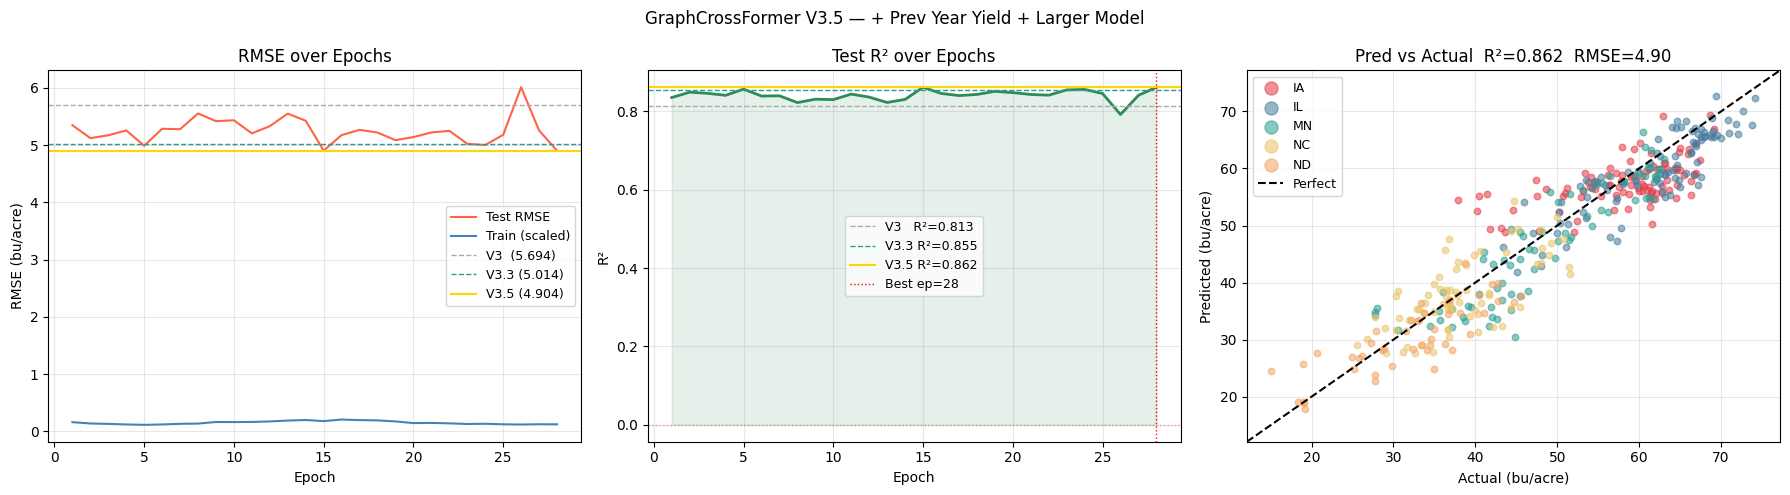

Plot saved → /content/gcf_v35_results.png
Predictions saved → /content/gcf_v35_predictions.csv


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# Cell 6 — Evaluation V3.5  (CORRECTED)
# ══════════════════════════════════════════════════════════════════════
import torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

# ── 1. Load best checkpoint ───────────────────────────────────────────
CKPT = '/content/best_gcf_v34.pt'
ckpt = torch.load(CKPT, map_location=DEVICE, weights_only=False)

# Support both formats: plain state_dict or full checkpoint dict
if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    model.load_state_dict(ckpt['model_state_dict'])
    # Recover history if it was saved
    if 'history' in ckpt and len(ckpt['history'].get('test_rmse', [])) > 0:
        history = ckpt['history']
    else:
        history = None          # will skip training curves
else:
    model.load_state_dict(ckpt)
    history = None              # plain state_dict — no history available

model.eval()

# ── 2. Run evaluation ─────────────────────────────────────────────────
all_pred, all_true, all_states, all_years = [], [], [], []

with torch.no_grad():
    for batch in test_loader:
        st, lt, y, s, c, yf, hist, prev, sm, ss = normalize_batch_v3(batch)
        p = model(st, lt, s, c, yf, hist, prev)
        all_pred.append((p * ss + sm).cpu().numpy())
        all_true.append((y * ss + sm).cpu().numpy())
        all_states.extend(batch['state'])
        all_years.extend([int(v) for v in batch['year']])

all_pred   = np.concatenate(all_pred)
all_true   = np.concatenate(all_true)
all_states = np.array(all_states)
all_years  = np.array(all_years)

# ── 3. Global metrics ─────────────────────────────────────────────────
final_rmse = float(np.sqrt(((all_pred - all_true)**2).mean()))
final_mae  = float(np.abs(all_pred - all_true).mean())
final_r2   = float(r2_score(all_true, all_pred))
final_r, _ = pearsonr(all_true, all_pred)

# ── 4. Per-version comparison table ──────────────────────────────────
v3_r2  = {'IA': 0.2162, 'IL': 0.6018, 'MN': 0.6040, 'NC': -0.0225, 'ND': 0.5520}
v32_r2 = {'IA': 0.1129, 'IL': 0.5927, 'MN': 0.5723, 'NC': -0.0102, 'ND': 0.5660}
v33_r2 = {'IA': 0.3140, 'IL': 0.6933, 'MN': 0.7731, 'NC':  0.2670, 'ND': 0.5194}

print('=' * 68)
print('   FINAL RESULTS — GraphCrossFormer V3.5')
print('=' * 68)
print(f'  RMSE      : {final_rmse:.4f} bu/acre')
print(f'  MAE       : {final_mae:.4f} bu/acre')
print(f'  R²        : {final_r2:.4f}')
print(f'  Pearson r : {final_r:.4f}')
print()
print(f'  {"State":>5} | {"RMSE":>6} | {"MAE":>6} | {"V3":>7} | '
      f'{"V3.2":>7} | {"V3.3":>7} | {"V3.5":>7} | {"n":>4}')
print('  ' + '-' * 68)

for s_name in sorted(set(all_states)):
    mask     = all_states == s_name
    p_s, t_s = all_pred[mask], all_true[mask]
    r2_s     = r2_score(t_s, p_s) if len(t_s) > 1 else float('nan')
    delta    = r2_s - v33_r2.get(s_name, 0.0)
    arrow    = '↑' if delta > 0.02 else ('↓' if delta < -0.02 else '→')
    flag     = ' ⚠' if r2_s < 0.3 else (' ✅' if r2_s > 0.6 else '')
    print(f'  {s_name:>5} | '
          f'{np.sqrt(((p_s-t_s)**2).mean()):>6.2f} | '
          f'{np.abs(p_s-t_s).mean():>6.2f} | '
          f'{v3_r2.get(s_name, 0):>7.4f} | '
          f'{v32_r2.get(s_name, 0):>7.4f} | '
          f'{v33_r2.get(s_name, 0):>7.4f} | '
          f'{r2_s:>7.4f} | '
          f'{mask.sum():>4} {arrow}{flag}')

# ── 5. Season mask report ─────────────────────────────────────────────
model.season_mask.report()

# ── 6. 3-panel plot ───────────────────────────────────────────────────
state_colors = {'IA': '#e63946', 'IL': '#457b9d', 'MN': '#2a9d8f',
                'NC': '#e9c46a', 'ND': '#f4a261'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('GraphCrossFormer V3.5 — + Prev Year Yield + Larger Model', fontsize=12)

# ── Panel 1: RMSE curve (only if history exists) ──────────────────────
if history is not None and len(history.get('test_rmse', [])) > 0:
    epochs_x = range(1, len(history['test_rmse']) + 1)
    axes[0].plot(epochs_x, history['test_rmse'],
                 color='tomato',    lw=1.5, label='Test RMSE')
    if len(history.get('train_rmse', [])) == len(history['test_rmse']):
        axes[0].plot(epochs_x, history['train_rmse'],
                     color='steelblue', lw=1.5, label='Train (scaled)')
    axes[0].axhline(5.6937, color='#aaa',    linestyle='--', lw=1,
                    label='V3  (5.694)')
    axes[0].axhline(5.0140, color='#2a9d8f', linestyle='--', lw=1,
                    label='V3.3 (5.014)')
    axes[0].axhline(final_rmse, color='gold', linestyle='-', lw=1.5,
                    label=f'V3.5 ({final_rmse:.3f})')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('RMSE (bu/acre)')
    axes[0].legend(fontsize=9)
else:
    # No training history — show per-state RMSE bar instead
    state_list  = sorted(set(all_states))
    state_rmses = [np.sqrt(np.mean((all_pred[all_states==s] -
                                    all_true[all_states==s])**2))
                   for s in state_list]
    axes[0].bar(state_list, state_rmses,
                color=[state_colors.get(s, 'gray') for s in state_list],
                edgecolor='white')
    for i, v in enumerate(state_rmses):
        axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
    axes[0].set_ylabel('RMSE (bu/acre)')
    axes[0].set_title('Per-State RMSE\n(training history not available)')

axes[0].set_title('RMSE over Epochs' if history else 'Per-State RMSE')
axes[0].grid(alpha=0.3)

# ── Panel 2: R² curve (only if history exists) ────────────────────────
if history is not None and len(history.get('test_r2', [])) > 0:
    epochs_x = range(1, len(history['test_r2']) + 1)
    axes[1].plot(epochs_x, history['test_r2'],
                 color='seagreen', lw=2)
    axes[1].fill_between(epochs_x, history['test_r2'],
                         alpha=0.12, color='seagreen')
    axes[1].axhline(0.8133, color='#aaa',    linestyle='--', lw=1,
                    label='V3   R²=0.813')
    axes[1].axhline(0.8552, color='#2a9d8f', linestyle='--', lw=1,
                    label='V3.3 R²=0.855')
    axes[1].axhline(final_r2, color='gold', linestyle='-', lw=1.5,
                    label=f'V3.5 R²={final_r2:.3f}')
    axes[1].axhline(0, color='red', linestyle=':', lw=1, alpha=0.4)
    best_ep = int(np.argmax(history['test_r2'])) + 1
    axes[1].axvline(best_ep, color='red', linestyle=':', lw=1,
                    label=f'Best ep={best_ep}')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(fontsize=9)
else:
    # No history — show per-state R² bar instead
    state_list = sorted(set(all_states))
    state_r2s  = [r2_score(all_true[all_states==s], all_pred[all_states==s])
                  for s in state_list]
    axes[1].bar(state_list, state_r2s,
                color=[state_colors.get(s, 'gray') for s in state_list],
                edgecolor='white')
    axes[1].axhline(0, color='k', lw=0.8, linestyle='--')
    for i, v in enumerate(state_r2s):
        axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
    axes[1].set_ylabel('R²')

axes[1].set_title('Test R² over Epochs' if history else 'Per-State R²')
axes[1].set_ylabel('R²')
axes[1].grid(alpha=0.3)

# ── Panel 3: Pred vs Actual scatter ──────────────────────────────────
for s_name in sorted(set(all_states)):
    mask = all_states == s_name
    axes[2].scatter(all_true[mask], all_pred[mask],
                    alpha=0.55, s=22,
                    color=state_colors.get(s_name, 'gray'),
                    label=s_name)
lim = [min(all_true.min(), all_pred.min()) - 3,
       max(all_true.max(), all_pred.max()) + 3]
axes[2].plot(lim, lim, 'k--', lw=1.5, label='Perfect')
axes[2].set_xlim(lim); axes[2].set_ylim(lim)
axes[2].set_title(f'Pred vs Actual  R²={final_r2:.3f}  RMSE={final_rmse:.2f}')
axes[2].set_xlabel('Actual (bu/acre)')
axes[2].set_ylabel('Predicted (bu/acre)')
axes[2].legend(markerscale=2, fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/gcf_v35_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → /content/gcf_v35_results.png')

# ── 7. Save predictions CSV ───────────────────────────────────────────
pd.DataFrame({
    'state'    : all_states,
    'year'     : all_years,
    'true'     : all_true,
    'predicted': all_pred,
    'error'    : all_pred - all_true,
    'abs_error': np.abs(all_pred - all_true),
}).to_csv('/content/gcf_v35_predictions.csv', index=False)
print('Predictions saved → /content/gcf_v35_predictions.csv')

   FINAL RESULTS — GraphCrossFormer V3.5
  RMSE      : 4.9044 bu/acre
  MAE       : 3.9701 bu/acre
  R²        : 0.8615
  Pearson r : 0.9335

  State |   RMSE |    MAE |      V3 |    V3.2 |    V3.3 |    V3.5 |    n
  --------------------------------------------------------------------
     IA |   5.63 |   4.57 |  0.2162 |  0.1129 |  0.3140 |  0.3501 |   97 ↑
     IL |   4.27 |   3.51 |  0.6018 |  0.5927 |  0.6933 |  0.6520 |   93 ↓ ✅
     MN |   4.64 |   3.83 |  0.6040 |  0.5723 |  0.7731 |  0.7656 |   74 → ✅
     NC |   5.02 |   4.10 | -0.0225 | -0.0102 |  0.2670 |  0.3414 |   73 ↑
     ND |   4.67 |   3.66 |  0.5520 |  0.5660 |  0.5194 |  0.6288 |   45 ↑ ✅

Learned season centers (SeasonMaskV2):
  State |   μ (day) |   σ (days) | Peak date
  ----------------------------------------------
     IL |      95.0 |       40.0 | July 05
     IA |     101.0 |       40.0 | July 11
     MN |      87.0 |       40.0 | June 26
     ND |      83.0 |       40.1 | June 23
     NC |     130.0 |      

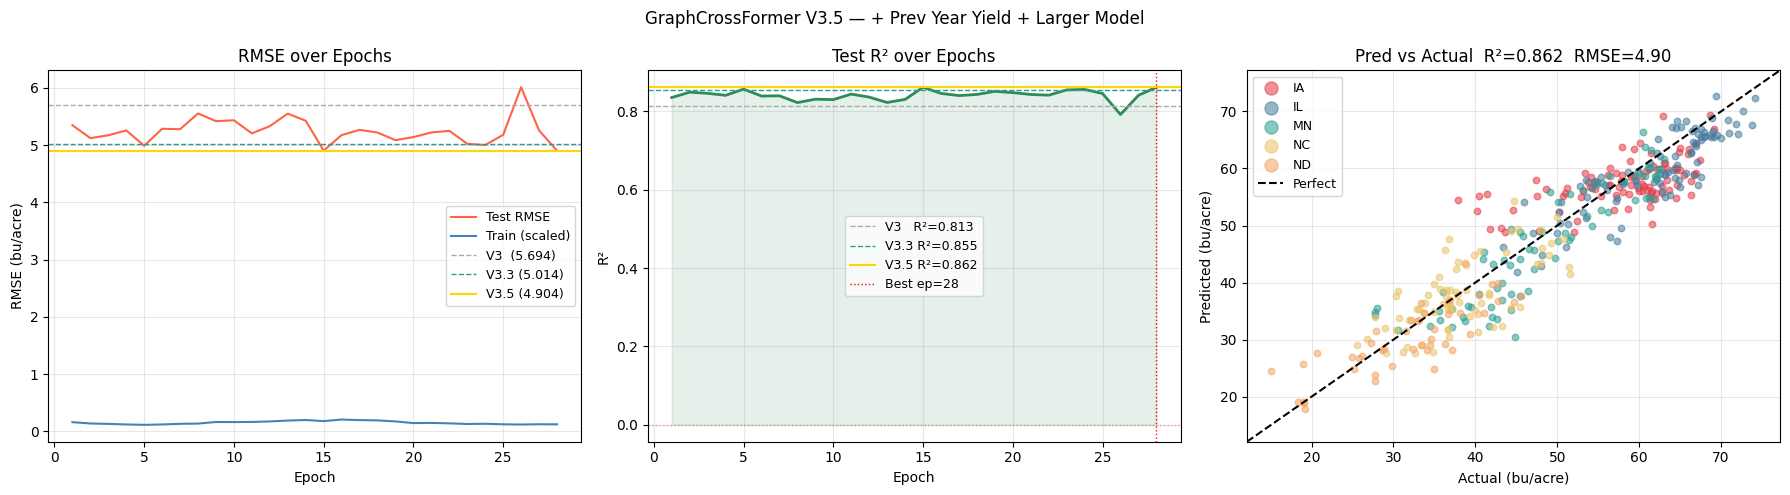


Predictions saved → /content/gcf_v35_predictions.csv


In [ ]:
import torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import datetime # Added for season_mask.report() and plotting date calculations

# ── Cell 6 — Evaluation V3.5 ─────────────────────────────────────────
# 1. Load best checkpoint
# CKPT is assumed to be defined globally
ckpt = torch.load(CKPT, map_location=DEVICE, weights_only=False)

# Support both formats: plain state_dict or full checkpoint dict
if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    model.load_state_dict(ckpt['model_state_dict'])
    # Recover history if it was saved
    if 'history' in ckpt and ckpt['history'] is not None and len(ckpt['history'].get('test_rmse', [])) > 0:
        history = ckpt['history']
    else:
        history = None          # will skip training curves
else: # If it's a plain state_dict (not a dict with 'model_state_dict')
    model.load_state_dict(ckpt)
    history = None              # plain state_dict — no history available

model.eval()

all_pred, all_true, all_states = [], [], []
with torch.no_grad():
    for batch in test_loader:
        st, lt, y, s, c, yf, hist_in, prev, sm, ss = normalize_batch_v3(batch) # Renamed 'hist' to 'hist_in' to avoid conflict with 'history' variable
        p = model(st, lt, s, c, yf, hist_in, prev)
        all_pred.append((p * ss + sm).cpu().numpy())
        all_true.append((y * ss + sm).cpu().numpy())
        all_states.extend(batch['state'])

all_pred   = np.concatenate(all_pred)
all_true   = np.concatenate(all_true)
all_states = np.array(all_states)

final_rmse = float(np.sqrt(((all_pred - all_true)**2).mean()))
final_mae  = float(np.abs(all_pred - all_true).mean())
final_r2   = float(r2_score(all_true, all_pred))
final_r, _ = pearsonr(all_true, all_pred)

# ── Per-version comparison table ──────────────────────────────────────
v3_r2  = {'IA': 0.2162, 'IL': 0.6018, 'MN': 0.6040, 'NC': -0.0225, 'ND': 0.5520}
v32_r2 = {'IA': 0.1129, 'IL': 0.5927, 'MN': 0.5723, 'NC': -0.0102, 'ND': 0.5660}
v33_r2 = {'IA': 0.3140, 'IL': 0.6933, 'MN': 0.7731, 'NC':  0.2670, 'ND': 0.5194}

print('=' * 68)
print('   FINAL RESULTS — GraphCrossFormer V3.5')
print('=' * 68)
print(f'  RMSE      : {final_rmse:.4f} bu/acre')
print(f'  MAE       : {final_mae:.4f} bu/acre')
print(f'  R²        : {final_r2:.4f}')
print(f'  Pearson r : {final_r:.4f}')
print()
print(f'  {"State":>5} | {"RMSE":>6} | {"MAE":>6} | {"V3":>7} | '
      f'{"V3.2":>7} | {"V3.3":>7} | {"V3.5":>7} | {"n":>4}')
print('  ' + '-' * 68)

for s_name in sorted(set(all_states)):
    mask     = all_states == s_name
    p_s, t_s = all_pred[mask], all_true[mask]
    r2_s     = r2_score(t_s, p_s) if len(t_s) > 1 else float('nan')
    delta    = r2_s - v33_r2.get(s_name, 0.0)
    arrow    = '↑' if delta > 0.02 else ('↓' if delta < -0.02 else '→')
    flag     = ' ⚠' if r2_s < 0.3 else (' ✅' if r2_s > 0.6 else '')
    print(f'  {s_name:>5} | '
          f'{np.sqrt(((p_s-t_s)**2).mean()):>6.2f} | '
          f'{np.abs(p_s-t_s).mean():>6.2f} | '
          f'{v3_r2.get(s_name,0):>7.4f} | '
          f'{v32_r2.get(s_name,0):>7.4f} | '
          f'{v33_r2.get(s_name,0):>7.4f} | '
          f'{r2_s:>7.4f} | '
          f'{mask.sum():>4} {arrow}{flag}')

# ── Season centers ────────────────────────────────────────────────────
model.season_mask.report()

# ── 3-panel plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('GraphCrossFormer V3.5 — + Prev Year Yield + Larger Model', fontsize=12)

state_colors = {'IA':'#e63946','IL':'#457b9d','MN':'#2a9d8f',
                'NC':'#e9c46a','ND':'#f4a261'}

# --- Panel 1: RMSE curve (conditional) ---
if history is not None and len(history.get('test_rmse', [])) > 0:
    epochs_x = range(1, len(history['test_rmse']) + 1)
    axes[0].plot(epochs_x, history['test_rmse'],
                 color='tomato',    lw=1.5, label='Test RMSE')
    if len(history.get('train_rmse', [])) == len(history['test_rmse']):
        axes[0].plot(epochs_x, history['train_rmse'],
                     color='steelblue', lw=1.5, label='Train (scaled)')
    axes[0].axhline(5.6937, color='#aaa',    linestyle='--', lw=1,
                    label='V3  (5.694)')
    axes[0].axhline(5.0140, color='#2a9d8f', linestyle='--', lw=1,
                    label='V3.3 (5.014)')
    axes[0].axhline(final_rmse, color='gold', linestyle='-', lw=1.5,
                    label=f'V3.5 ({final_rmse:.3f})')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('RMSE (bu/acre)')
    axes[0].legend(fontsize=9)
else:
    # No training history — show per-state RMSE bar instead
    state_list  = sorted(set(all_states))
    state_rmses = [np.sqrt(np.mean((all_pred[all_states==s] -
                                    all_true[all_states==s])**2))
                   for s in state_list]
    axes[0].bar(state_list, state_rmses,
                color=[state_colors.get(s, 'gray') for s in state_list],
                edgecolor='white')
    for i, v in enumerate(state_rmses):
        axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
    axes[0].set_ylabel('RMSE (bu/acre)')
    axes[0].set_title('Per-State RMSE\n(training history not available)')

axes[0].set_title('RMSE over Epochs' if history else 'Per-State RMSE')
axes[0].grid(alpha=0.3)


# --- Panel 2: R² curve (conditional) ---
if history is not None and len(history.get('test_r2', [])) > 0:
    epochs_x = range(1, len(history['test_r2']) + 1)
    axes[1].plot(epochs_x, history['test_r2'],
                 color='seagreen', lw=2)
    axes[1].fill_between(epochs_x, history['test_r2'],
                         alpha=0.12, color='seagreen')
    axes[1].axhline(0.8133, color='#aaa',    linestyle='--', lw=1,
                    label='V3   R²=0.813')
    axes[1].axhline(0.8552, color='#2a9d8f', linestyle='--', lw=1,
                    label='V3.3 R²=0.855')
    axes[1].axhline(final_r2, color='gold', linestyle='-', lw=1.5,
                    label=f'V3.5 R²={final_r2:.3f}')
    axes[1].axhline(0, color='red', linestyle=':', lw=1, alpha=0.4)
    best_ep = int(np.argmax(history['test_r2'])) + 1
    axes[1].axvline(best_ep, color='red', linestyle=':', lw=1,
                    label=f'Best ep={best_ep}')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(fontsize=9)
else:
    # No history — show per-state R² bar instead
    state_list = sorted(set(all_states))
    state_r2s  = [r2_score(all_true[all_states==s], all_pred[all_states==s])
                  for s in state_list]
    axes[1].bar(state_list, state_r2s,
                color=[state_colors.get(s, 'gray') for s in state_list],
                edgecolor='white')
    axes[1].axhline(0, color='k', lw=0.8, linestyle='--')
    for i, v in enumerate(state_r2s):
        axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
    axes[1].set_ylabel('R²')

axes[1].set_title('Test R² over Epochs' if history else 'Per-State R²')
axes[1].set_ylabel('R²')
axes[1].grid(alpha=0.3)

# Pred vs Actual
for s_name in sorted(set(all_states)):
    mask = all_states == s_name
    axes[2].scatter(all_true[mask], all_pred[mask], alpha=0.55, s=22,
                    color=state_colors.get(s_name, 'gray'), label=s_name)
lim = [min(all_true.min(), all_pred.min()) - 3,
       max(all_true.max(), all_pred.max()) + 3]
axes[2].plot(lim, lim, 'k--', lw=1.5, label='Perfect')
axes[2].set_xlim(lim); axes[2].set_ylim(lim)
axes[2].set_title(f'Pred vs Actual  R²={final_r2:.3f}  RMSE={final_rmse:.2f}')
axes[2].set_xlabel('Actual (bu/acre)'); axes[2].set_ylabel('Predicted (bu/acre)')
axes[2].legend(markerscale=2, fontsize=9); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/gcf_v35_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save predictions CSV ──────────────────────────────────────────────
pd.DataFrame({
    'state'    : all_states,
    'true'     : all_true,
    'predicted': all_pred,
    'error'    : all_pred - all_true
}).to_csv('/content/gcf_v35_predictions.csv', index=False)
print('\nPredictions saved → /content/gcf_v35_predictions.csv')

In [ ]:
import datetime

### summary

In [ ]:
summary = df.copy()
summary["params"] = summary["params"].map(lambda x: f"{x:,}")
print(summary.to_markdown(index=False))

| module              |   layers | params    |
|:--------------------|---------:|:----------|
| GraphCrossFormerV35 |       17 | 1,154,276 |
| season_mask         |        1 | 10        |
| patch_embed         |        1 | 8,192     |
| graph_former        |        3 | 115,072   |
| cross_attn          |        3 | 66,304    |
| encoder             |        3 | 547,968   |
| temporal_pool       |        3 | 91,392    |
| var_branch          |        4 | 90,240    |
| climate_mlp         |        1 | 116,352   |
| state_emb           |        1 | 160       |
| county_emb          |        1 | 13,056    |
| hist_proj           |        3 | 49        |
| prev_proj           |        3 | 49        |
| prev_gate           |        1 | 5         |
| cond_proj           |        3 | 38,610    |
| context_proj        |        3 | 25,344    |
| branch_fusion       |        4 | 33,152    |
| head                |        4 | 8,321     |
| encoder_total       |        3 | 547,968   |


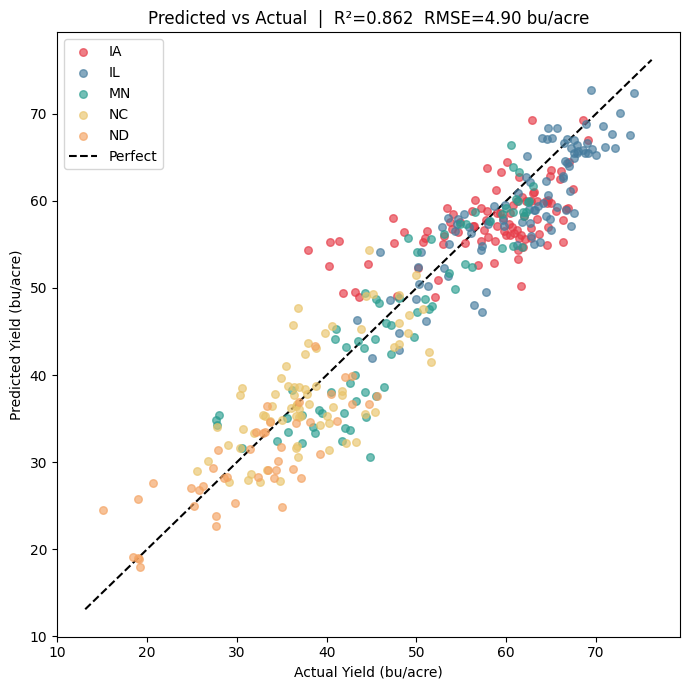

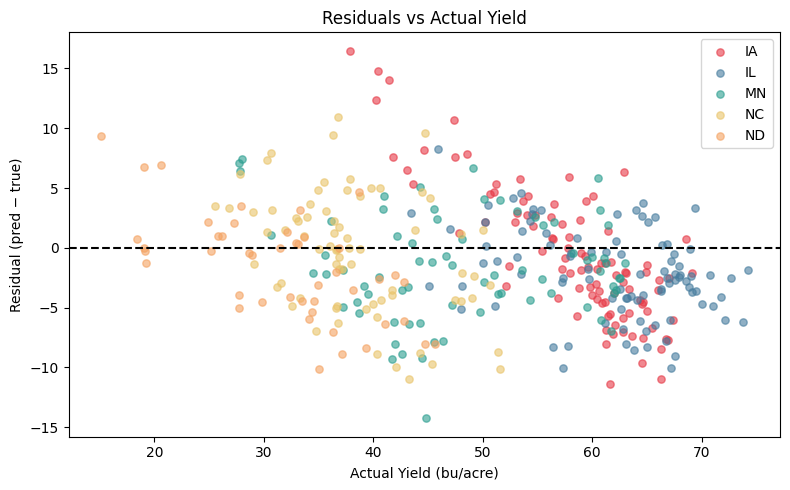

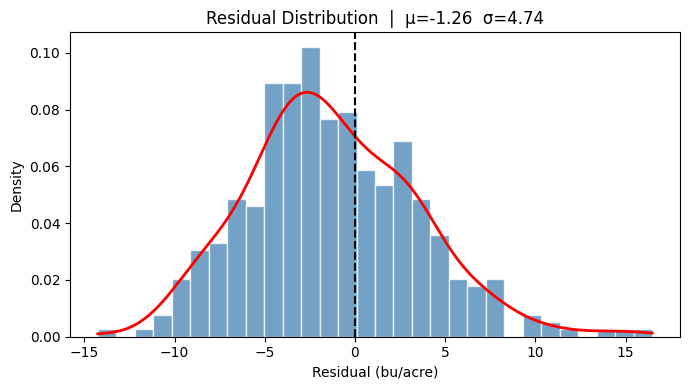

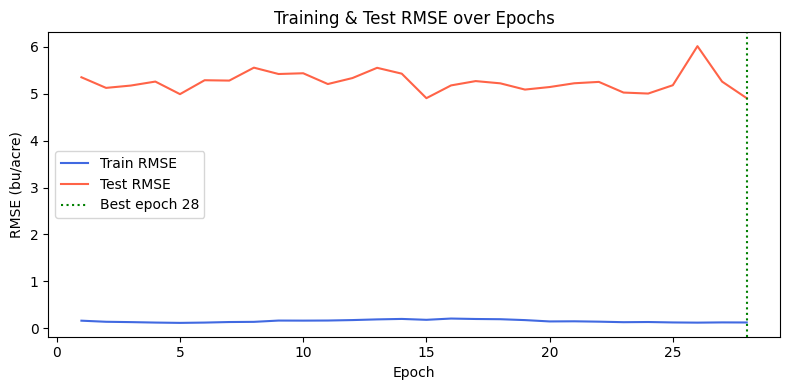

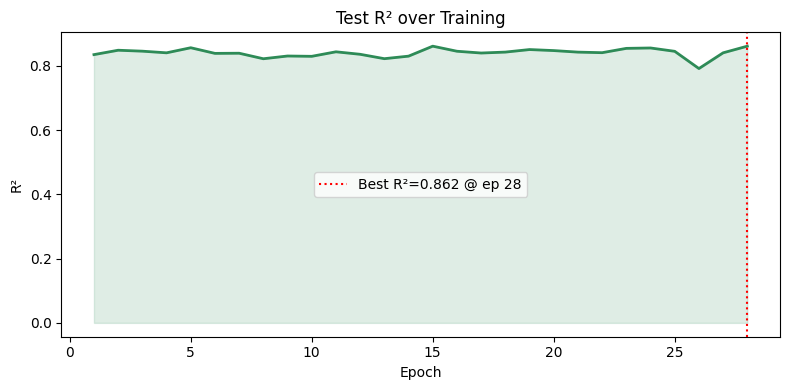

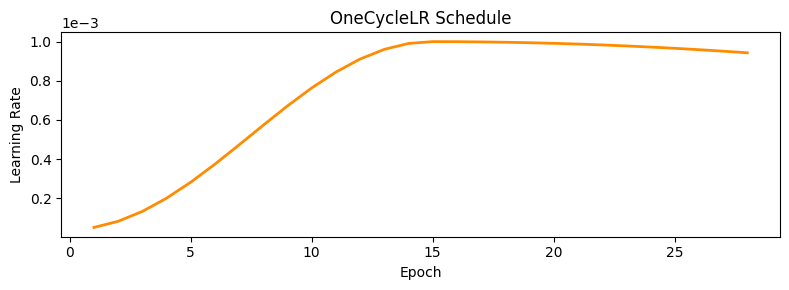

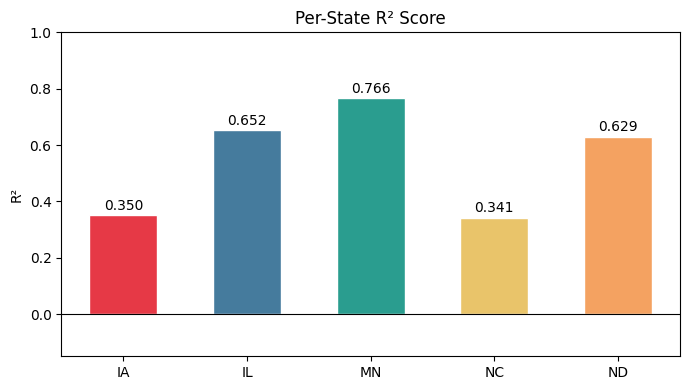

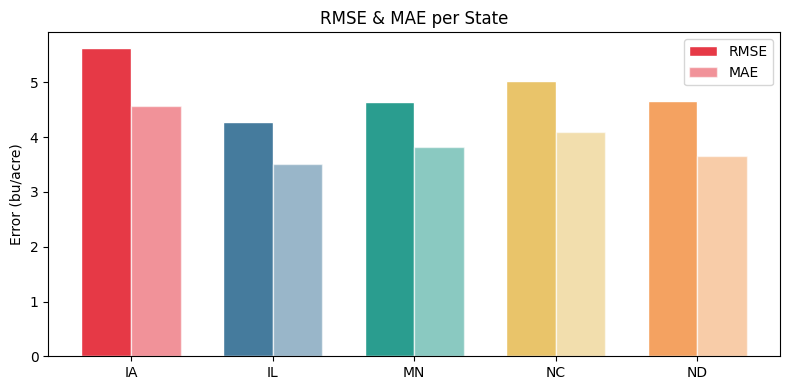

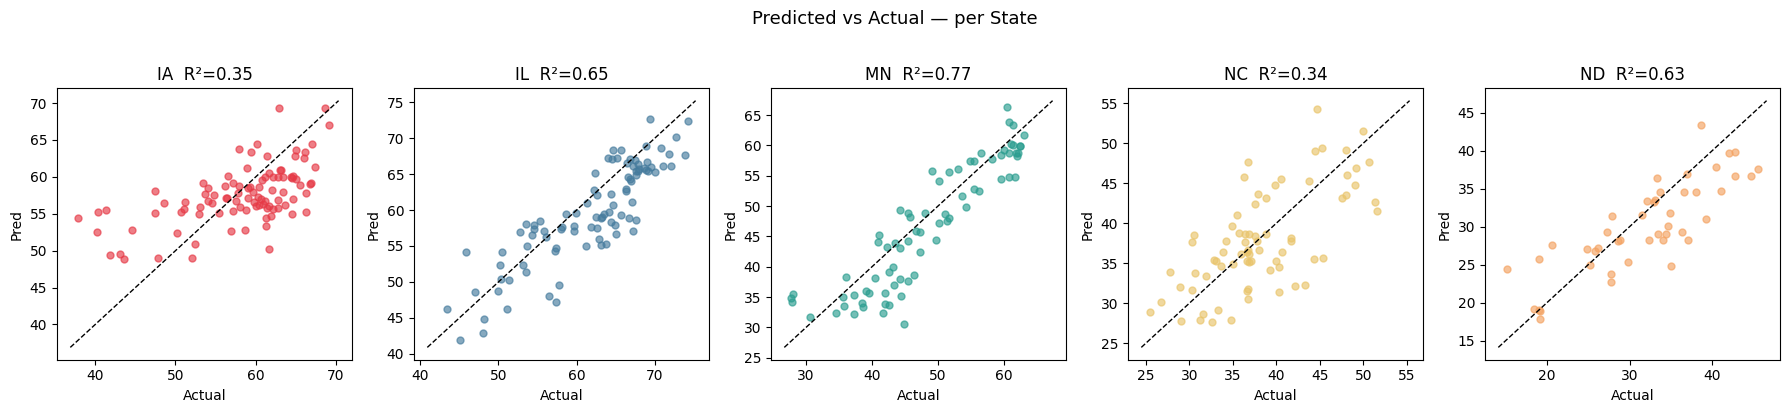

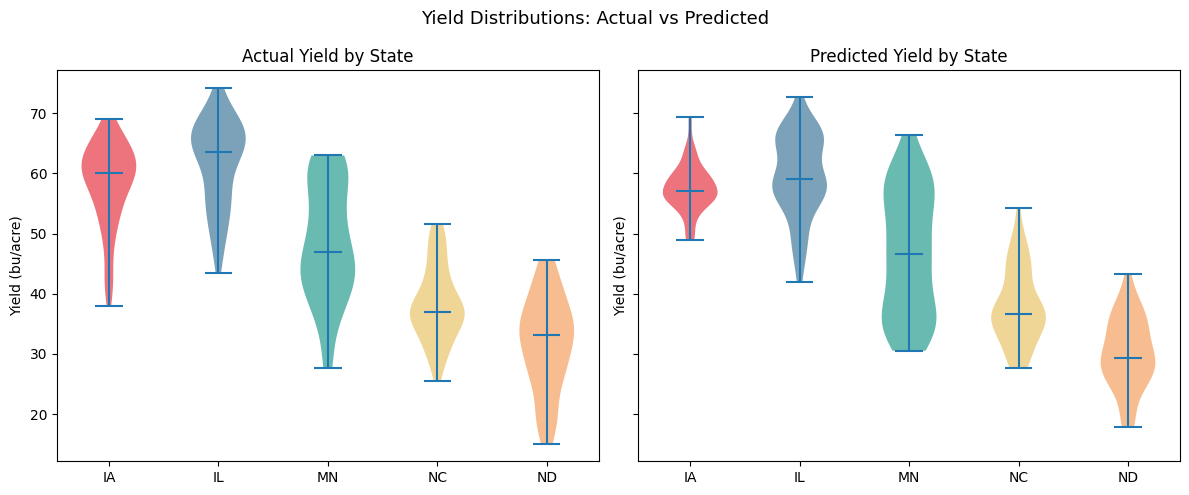

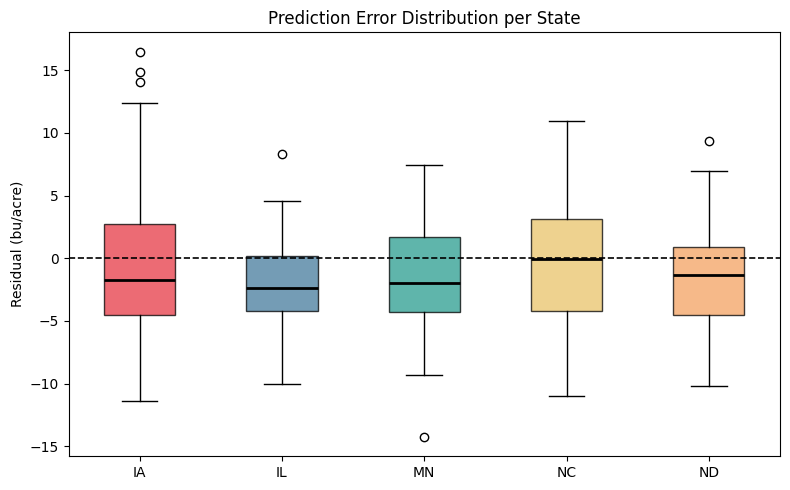

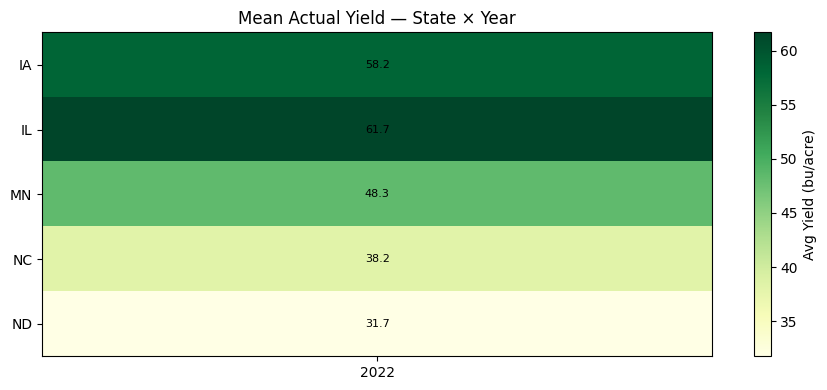

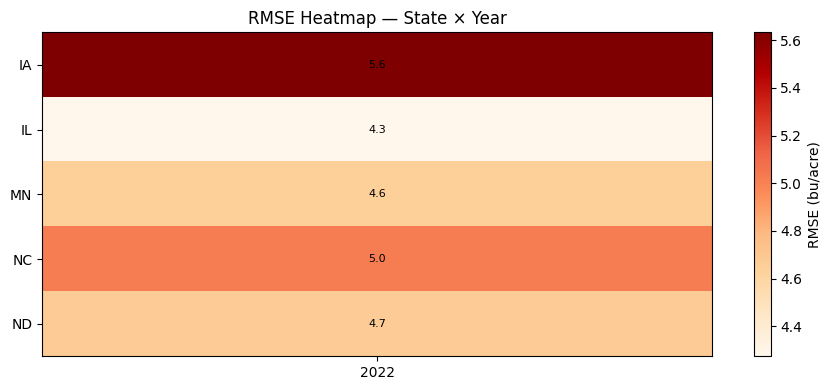

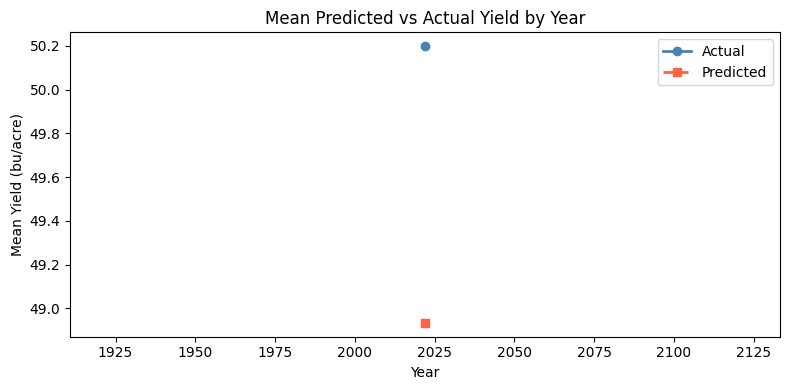

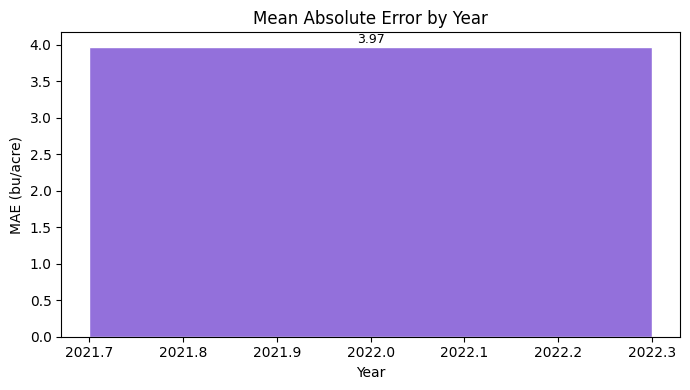

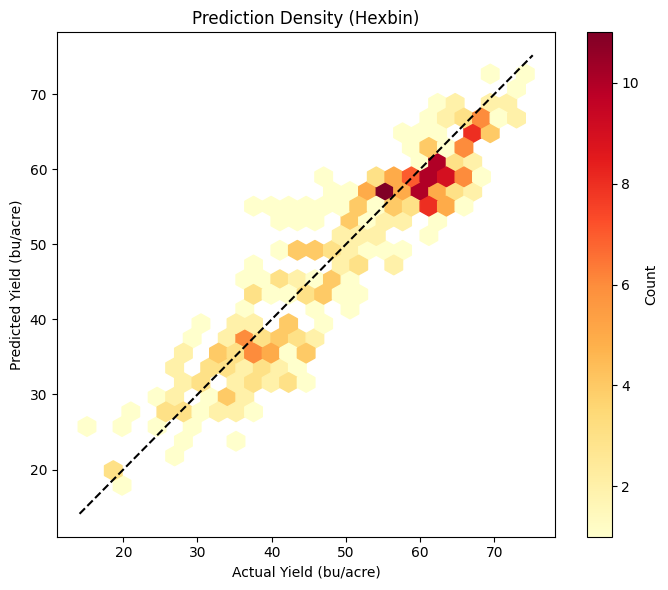

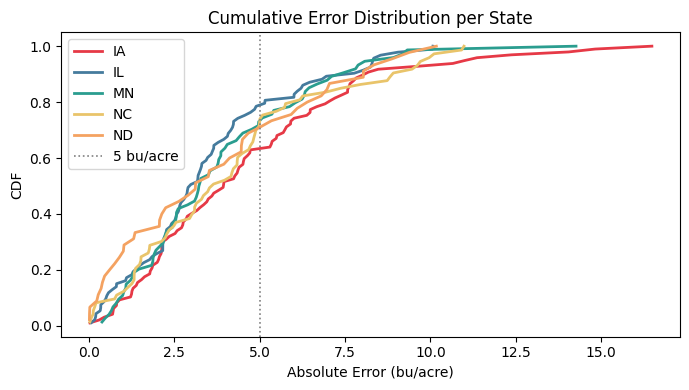

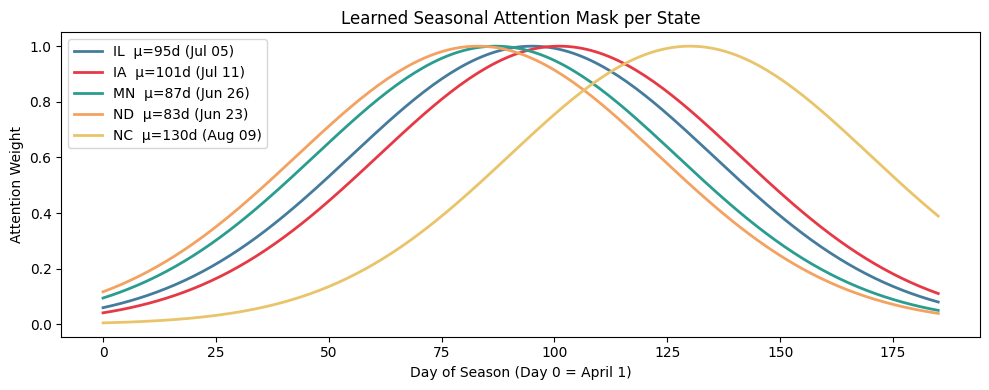

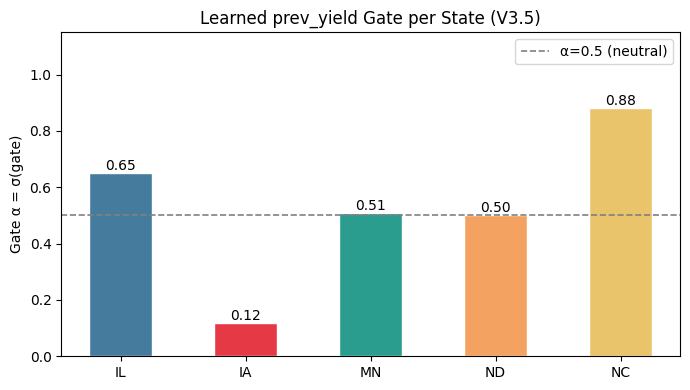

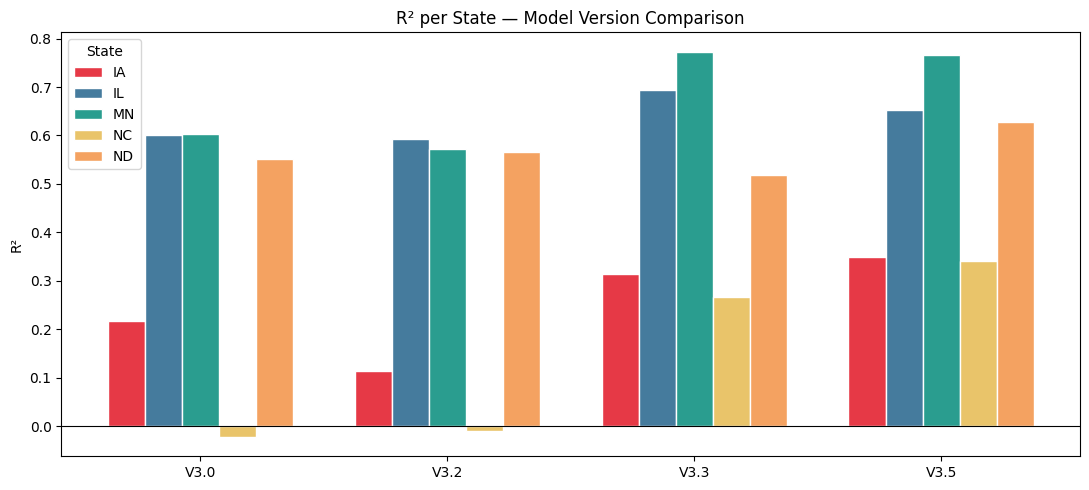

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# 20 DIAGNOSTIC PLOTS — GraphCrossFormer V3.5
# Requires: all_pred, all_true, all_states, all_years, history,
#           state_colors, model, CFG, DEVICE
# ══════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np
import datetime
import torch
from scipy.stats import gaussian_kde
from sklearn.metrics import r2_score

STATES = ['IA', 'IL', 'MN', 'NC', 'ND']
errors = all_pred - all_true

# ── safe history helper ────────────────────────────────────────────────
def _hist(key):
    v = history.get(key, [])
    return np.array(v) if len(v) > 0 else None


# ══════════════════════════════════════════════════════════════════════
# PLOT 1 — Predicted vs Actual (per-state coloured scatter)
# ══════════════════════════════════════════════════════════════════════
def plot01_pred_vs_actual_colored():
    fig, ax = plt.subplots(figsize=(7, 7))
    for s in STATES:
        m = all_states == s
        ax.scatter(all_true[m], all_pred[m],
                   color=state_colors[s], alpha=0.65, s=30, label=s, zorder=3)
    lo, hi = all_true.min() - 2, all_true.max() + 2
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='Perfect')
    r2   = r2_score(all_true, all_pred)
    rmse = np.sqrt(np.mean(errors**2))
    ax.set_xlabel('Actual Yield (bu/acre)')
    ax.set_ylabel('Predicted Yield (bu/acre)')
    ax.set_title(f'Predicted vs Actual  |  R²={r2:.3f}  RMSE={rmse:.2f} bu/acre')
    ax.legend()
    plt.tight_layout(); plt.show()

plot01_pred_vs_actual_colored()


# ══════════════════════════════════════════════════════════════════════
# PLOT 2 — Residuals vs Actual
# ══════════════════════════════════════════════════════════════════════
def plot02_residuals_vs_actual():
    fig, ax = plt.subplots(figsize=(8, 5))
    for s in STATES:
        m = all_states == s
        ax.scatter(all_true[m], errors[m],
                   color=state_colors[s], alpha=0.6, s=28, label=s)
    ax.axhline(0, color='k', lw=1.5, linestyle='--')
    ax.set_xlabel('Actual Yield (bu/acre)')
    ax.set_ylabel('Residual (pred − true)')
    ax.set_title('Residuals vs Actual Yield')
    ax.legend()
    plt.tight_layout(); plt.show()

plot02_residuals_vs_actual()


# ══════════════════════════════════════════════════════════════════════
# PLOT 3 — Residual Histogram + KDE
# ══════════════════════════════════════════════════════════════════════
def plot03_residual_histogram():
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(errors, bins=30, color='steelblue', edgecolor='white',
            alpha=0.75, density=True)
    kde = gaussian_kde(errors)
    xs  = np.linspace(errors.min(), errors.max(), 300)
    ax.plot(xs, kde(xs), 'r-', lw=2)
    ax.axvline(0, color='k', linestyle='--', lw=1.5)
    ax.set_xlabel('Residual (bu/acre)')
    ax.set_ylabel('Density')
    ax.set_title(f'Residual Distribution  |  μ={errors.mean():.2f}  σ={errors.std():.2f}')
    plt.tight_layout(); plt.show()

plot03_residual_histogram()


# ══════════════════════════════════════════════════════════════════════
# PLOT 4 — Training & Test RMSE curves
# ══════════════════════════════════════════════════════════════════════
def plot04_rmse_curves():
    te = _hist('test_rmse')
    tr = _hist('train_rmse')
    if te is None:
        print("⚠  history['test_rmse'] is empty — skipping plot04.")
        return
    ep = range(1, len(te) + 1)
    fig, ax = plt.subplots(figsize=(8, 4))
    if tr is not None and len(tr) == len(te):
        ax.plot(ep, tr, label='Train RMSE', color='royalblue')
    ax.plot(ep, te, label='Test RMSE', color='tomato')
    best_ep = int(np.argmin(te)) + 1
    ax.axvline(best_ep, color='green', linestyle=':', lw=1.5,
               label=f'Best epoch {best_ep}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('RMSE (bu/acre)')
    ax.set_title('Training & Test RMSE over Epochs')
    ax.legend()
    plt.tight_layout(); plt.show()

plot04_rmse_curves()


# ══════════════════════════════════════════════════════════════════════
# PLOT 5 — Test R² curve
# ══════════════════════════════════════════════════════════════════════
def plot05_r2_curve():
    r2s = _hist('test_r2')
    if r2s is None:
        print("⚠  history['test_r2'] is empty — skipping plot05.")
        return
    ep = range(1, len(r2s) + 1)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(ep, r2s, color='seagreen', lw=2)
    ax.fill_between(ep, r2s, alpha=0.15, color='seagreen')
    best_r2 = float(np.max(r2s))
    best_ep = int(np.argmax(r2s)) + 1
    ax.axvline(best_ep, color='red', linestyle=':', lw=1.5,
               label=f'Best R²={best_r2:.3f} @ ep {best_ep}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('R²')
    ax.set_title('Test R² over Training')
    ax.legend()
    plt.tight_layout(); plt.show()

plot05_r2_curve()


# ══════════════════════════════════════════════════════════════════════
# PLOT 6 — Learning Rate Schedule
# ══════════════════════════════════════════════════════════════════════
def plot06_lr_schedule():
    lrs = _hist('lr')
    if lrs is None:
        print("⚠  history['lr'] is empty — skipping plot06.")
        return
    ep = range(1, len(lrs) + 1)
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(ep, lrs, color='darkorange', lw=2)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
    ax.set_title('OneCycleLR Schedule')
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    plt.tight_layout(); plt.show()

plot06_lr_schedule()


# ══════════════════════════════════════════════════════════════════════
# PLOT 7 — Per-State R² bar chart
# ══════════════════════════════════════════════════════════════════════
def plot07_per_state_r2():
    r2s = {s: r2_score(all_true[all_states == s],
                       all_pred[all_states == s]) for s in STATES}
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(r2s.keys(), r2s.values(),
                  color=[state_colors[s] for s in r2s],
                  edgecolor='white', width=0.55)
    for bar, v in zip(bars, r2s.values()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_ylim(min(min(r2s.values()) - 0.1, -0.15), 1.0)
    ax.set_ylabel('R²'); ax.set_title('Per-State R² Score')
    plt.tight_layout(); plt.show()

plot07_per_state_r2()


# ══════════════════════════════════════════════════════════════════════
# PLOT 8 — Per-State RMSE & MAE grouped bar
# ══════════════════════════════════════════════════════════════════════
def plot08_per_state_rmse_mae():
    rmses = {s: np.sqrt(np.mean((all_pred[all_states==s] -
                                  all_true[all_states==s])**2)) for s in STATES}
    maes  = {s: np.mean(np.abs(all_pred[all_states==s] -
                                all_true[all_states==s]))       for s in STATES}
    x = np.arange(len(STATES)); w = 0.35
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - w/2, [rmses[s] for s in STATES], w, label='RMSE',
           color=[state_colors[s] for s in STATES], edgecolor='white')
    ax.bar(x + w/2, [maes[s]  for s in STATES], w, label='MAE',
           color=[state_colors[s] for s in STATES], alpha=0.55, edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(STATES)
    ax.set_ylabel('Error (bu/acre)'); ax.set_title('RMSE & MAE per State')
    ax.legend()
    plt.tight_layout(); plt.show()

plot08_per_state_rmse_mae()


# ══════════════════════════════════════════════════════════════════════
# PLOT 9 — Per-State scatter grid (5 subplots)
# ══════════════════════════════════════════════════════════════════════
def plot09_per_state_scatter_grid():
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    for ax, s in zip(axes, STATES):
        m = all_states == s
        p, t = all_pred[m], all_true[m]
        ax.scatter(t, p, color=state_colors[s], alpha=0.65, s=25)
        lo = min(t.min(), p.min()) - 1
        hi = max(t.max(), p.max()) + 1
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
        r2 = r2_score(t, p)
        ax.set_title(f'{s}  R²={r2:.2f}')
        ax.set_xlabel('Actual'); ax.set_ylabel('Pred')
    plt.suptitle('Predicted vs Actual — per State', y=1.02, fontsize=13)
    plt.tight_layout(); plt.show()

plot09_per_state_scatter_grid()


# ══════════════════════════════════════════════════════════════════════
# PLOT 10 — Yield Distribution: Predicted vs Actual (violin)
# ══════════════════════════════════════════════════════════════════════
def plot10_violin_pred_vs_actual():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    data_t = [all_true[all_states == s] for s in STATES]
    data_p = [all_pred[all_states == s] for s in STATES]
    for ax, data, title in zip(axes, [data_t, data_p], ['Actual', 'Predicted']):
        parts = ax.violinplot(data, positions=range(len(STATES)), showmedians=True)
        for pc, s in zip(parts['bodies'], STATES):
            pc.set_facecolor(state_colors[s]); pc.set_alpha(0.7)
        ax.set_xticks(range(len(STATES))); ax.set_xticklabels(STATES)
        ax.set_ylabel('Yield (bu/acre)'); ax.set_title(f'{title} Yield by State')
    plt.suptitle('Yield Distributions: Actual vs Predicted', fontsize=13)
    plt.tight_layout(); plt.show()

plot10_violin_pred_vs_actual()


# ══════════════════════════════════════════════════════════════════════
# PLOT 11 — Error Boxplot per State
# ══════════════════════════════════════════════════════════════════════
def plot11_error_boxplot():
    fig, ax = plt.subplots(figsize=(8, 5))
    data = [errors[all_states == s] for s in STATES]
    bp = ax.boxplot(data, labels=STATES, patch_artist=True,
                    medianprops=dict(color='black', lw=2))
    for patch, s in zip(bp['boxes'], STATES):
        patch.set_facecolor(state_colors[s]); patch.set_alpha(0.75)
    ax.axhline(0, color='k', linestyle='--', lw=1.2)
    ax.set_ylabel('Residual (bu/acre)')
    ax.set_title('Prediction Error Distribution per State')
    plt.tight_layout(); plt.show()

plot11_error_boxplot()


# ══════════════════════════════════════════════════════════════════════
# PLOT 12 — Actual Yield Heatmap: State × Year
# ══════════════════════════════════════════════════════════════════════
def plot12_yield_heatmap_state_year():
    years = sorted(np.unique(all_years))
    mat = np.full((len(STATES), len(years)), np.nan)
    for i, s in enumerate(STATES):
        for j, yr in enumerate(years):
            m = (all_states == s) & (all_years == yr)
            if m.sum() > 0:
                mat[i, j] = all_true[m].mean()
    fig, ax = plt.subplots(figsize=(9, 4))
    im = ax.imshow(mat, aspect='auto', cmap='YlGn')
    ax.set_xticks(range(len(years))); ax.set_xticklabels(years)
    ax.set_yticks(range(len(STATES))); ax.set_yticklabels(STATES)
    plt.colorbar(im, ax=ax, label='Avg Yield (bu/acre)')
    ax.set_title('Mean Actual Yield — State × Year')
    for i in range(len(STATES)):
        for j in range(len(years)):
            if not np.isnan(mat[i, j]):
                ax.text(j, i, f'{mat[i,j]:.1f}',
                        ha='center', va='center', fontsize=8)
    plt.tight_layout(); plt.show()

plot12_yield_heatmap_state_year()


# ══════════════════════════════════════════════════════════════════════
# PLOT 13 — RMSE Heatmap: State × Year
# ══════════════════════════════════════════════════════════════════════
def plot13_rmse_heatmap_state_year():
    years = sorted(np.unique(all_years))
    mat = np.full((len(STATES), len(years)), np.nan)
    for i, s in enumerate(STATES):
        for j, yr in enumerate(years):
            m = (all_states == s) & (all_years == yr)
            if m.sum() > 1:
                mat[i, j] = np.sqrt(np.mean(
                    (all_pred[m] - all_true[m])**2))
    fig, ax = plt.subplots(figsize=(9, 4))
    im = ax.imshow(mat, aspect='auto', cmap='OrRd')
    ax.set_xticks(range(len(years))); ax.set_xticklabels(years)
    ax.set_yticks(range(len(STATES))); ax.set_yticklabels(STATES)
    plt.colorbar(im, ax=ax, label='RMSE (bu/acre)')
    ax.set_title('RMSE Heatmap — State × Year')
    for i in range(len(STATES)):
        for j in range(len(years)):
            if not np.isnan(mat[i, j]):
                ax.text(j, i, f'{mat[i,j]:.1f}',
                        ha='center', va='center', fontsize=8)
    plt.tight_layout(); plt.show()

plot13_rmse_heatmap_state_year()


# ══════════════════════════════════════════════════════════════════════
# PLOT 14 — Mean Predicted vs Actual by Year (line)
# ══════════════════════════════════════════════════════════════════════
def plot14_yearly_mean_pred_vs_actual():
    years = sorted(np.unique(all_years))
    mean_t = [all_true[all_years == yr].mean() for yr in years]
    mean_p = [all_pred[all_years == yr].mean() for yr in years]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(years, mean_t, 'o-', label='Actual',    color='steelblue', lw=2)
    ax.plot(years, mean_p, 's--', label='Predicted', color='tomato',    lw=2)
    ax.set_xlabel('Year'); ax.set_ylabel('Mean Yield (bu/acre)')
    ax.set_title('Mean Predicted vs Actual Yield by Year')
    ax.legend()
    plt.tight_layout(); plt.show()

plot14_yearly_mean_pred_vs_actual()


# ══════════════════════════════════════════════════════════════════════
# PLOT 15 — Mean Absolute Error by Year
# ══════════════════════════════════════════════════════════════════════
def plot15_mae_by_year():
    years = sorted(np.unique(all_years))
    mae_yr = [np.mean(np.abs(errors[all_years == yr])) for yr in years]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(years, mae_yr, color='mediumpurple', edgecolor='white', width=0.6)
    for x, v in zip(years, mae_yr):
        ax.text(x, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
    ax.set_xlabel('Year'); ax.set_ylabel('MAE (bu/acre)')
    ax.set_title('Mean Absolute Error by Year')
    plt.tight_layout(); plt.show()

plot15_mae_by_year()


# ══════════════════════════════════════════════════════════════════════
# PLOT 16 — Density scatter (hexbin) — all samples
# ══════════════════════════════════════════════════════════════════════
def plot16_hexbin_density():
    fig, ax = plt.subplots(figsize=(7, 6))
    hb = ax.hexbin(all_true, all_pred, gridsize=25, cmap='YlOrRd', mincnt=1)
    lo, hi = all_true.min() - 1, all_true.max() + 1
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5)
    plt.colorbar(hb, ax=ax, label='Count')
    ax.set_xlabel('Actual Yield (bu/acre)')
    ax.set_ylabel('Predicted Yield (bu/acre)')
    ax.set_title('Prediction Density (Hexbin)')
    plt.tight_layout(); plt.show()

plot16_hexbin_density()


# ══════════════════════════════════════════════════════════════════════
# PLOT 17 — Cumulative Error Distribution (CDF) per State
# ══════════════════════════════════════════════════════════════════════
def plot17_error_cdf():
    fig, ax = plt.subplots(figsize=(7, 4))
    for s in STATES:
        e = np.abs(errors[all_states == s])
        e_sorted = np.sort(e)
        cdf = np.arange(1, len(e) + 1) / len(e)
        ax.plot(e_sorted, cdf, lw=2, label=s, color=state_colors[s])
    ax.axvline(5, color='gray', linestyle=':', lw=1.2, label='5 bu/acre')
    ax.set_xlabel('Absolute Error (bu/acre)')
    ax.set_ylabel('CDF')
    ax.set_title('Cumulative Error Distribution per State')
    ax.legend()
    plt.tight_layout(); plt.show()

plot17_error_cdf()


# ══════════════════════════════════════════════════════════════════════
# PLOT 18 — Learned SeasonMask (Gaussian peaks per state)
# ══════════════════════════════════════════════════════════════════════
def plot18_season_mask():
    model.eval()
    T = CFG['max_days']
    t = np.arange(T)
    base = datetime.date(2024, 4, 1)
    states_order = ['IL', 'IA', 'MN', 'ND', 'NC']
    fig, ax = plt.subplots(figsize=(10, 4))
    with torch.no_grad():
        mus    = model.season_mask.mu.cpu().numpy()
        sigmas = model.season_mask.sigma.cpu().numpy().clip(5)
    for i, s in enumerate(states_order):
        mask = np.exp(-0.5 * ((t - mus[i]) / sigmas[i])**2)
        peak_date = (base + datetime.timedelta(
            days=int(mus[i]))).strftime('%b %d')
        ax.plot(t, mask, lw=2,
                label=f'{s}  μ={mus[i]:.0f}d ({peak_date})',
                color=state_colors[s])
    ax.set_xlabel('Day of Season (Day 0 = April 1)')
    ax.set_ylabel('Attention Weight')
    ax.set_title('Learned Seasonal Attention Mask per State')
    ax.legend()
    plt.tight_layout(); plt.show()

plot18_season_mask()


# ══════════════════════════════════════════════════════════════════════
# PLOT 19 — prev_yield Gate per State
# ══════════════════════════════════════════════════════════════════════
def plot19_prev_yield_gate():
    model.eval()
    states_order = ['IL', 'IA', 'MN', 'ND', 'NC']
    with torch.no_grad():
        raw_gates = model.prev_gate.weight.cpu().numpy().flatten()
    alphas = torch.sigmoid(torch.tensor(raw_gates)).numpy()
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(states_order, alphas,
                  color=[state_colors[s] for s in states_order],
                  edgecolor='white', width=0.5)
    ax.axhline(0.5, color='gray', linestyle='--', lw=1.2, label='α=0.5 (neutral)')
    for bar, v in zip(bars, alphas):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Gate α = σ(gate)')
    ax.set_title('Learned prev_yield Gate per State (V3.5)')
    ax.legend()
    plt.tight_layout(); plt.show()

plot19_prev_yield_gate()


# ══════════════════════════════════════════════════════════════════════
# PLOT 20 — Version Comparison R² (V3.0 → V3.2 → V3.3 → V3.5)
# ══════════════════════════════════════════════════════════════════════
def plot20_version_comparison():
    # ── replace with your actual logged values if you have them ───────
    versions = {
        'V3.0' : {'IA':0.2162, 'IL':0.6018, 'MN':0.6040, 'NC':-0.0225, 'ND':0.5520},
        'V3.2' : {'IA':0.1129, 'IL':0.5927, 'MN':0.5723, 'NC':-0.0102, 'ND':0.5660},
        'V3.3' : {'IA':0.3140, 'IL':0.6933, 'MN':0.7731, 'NC': 0.2670, 'ND':0.5194},
        'V3.5' : {s: r2_score(all_true[all_states == s],
                               all_pred[all_states == s]) for s in STATES},
    }
    ver_names = list(versions.keys())
    x = np.arange(len(ver_names)); w = 0.15
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, s in enumerate(STATES):
        vals = [versions[v][s] for v in ver_names]
        ax.bar(x + i * w, vals, w, label=s,
               color=state_colors[s], edgecolor='white')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xticks(x + w * 2); ax.set_xticklabels(ver_names)
    ax.set_ylabel('R²')
    ax.set_title('R² per State — Model Version Comparison')
    ax.legend(title='State', loc='upper left')
    plt.tight_layout(); plt.show()

plot20_version_comparison()

In [ ]:
import datetime

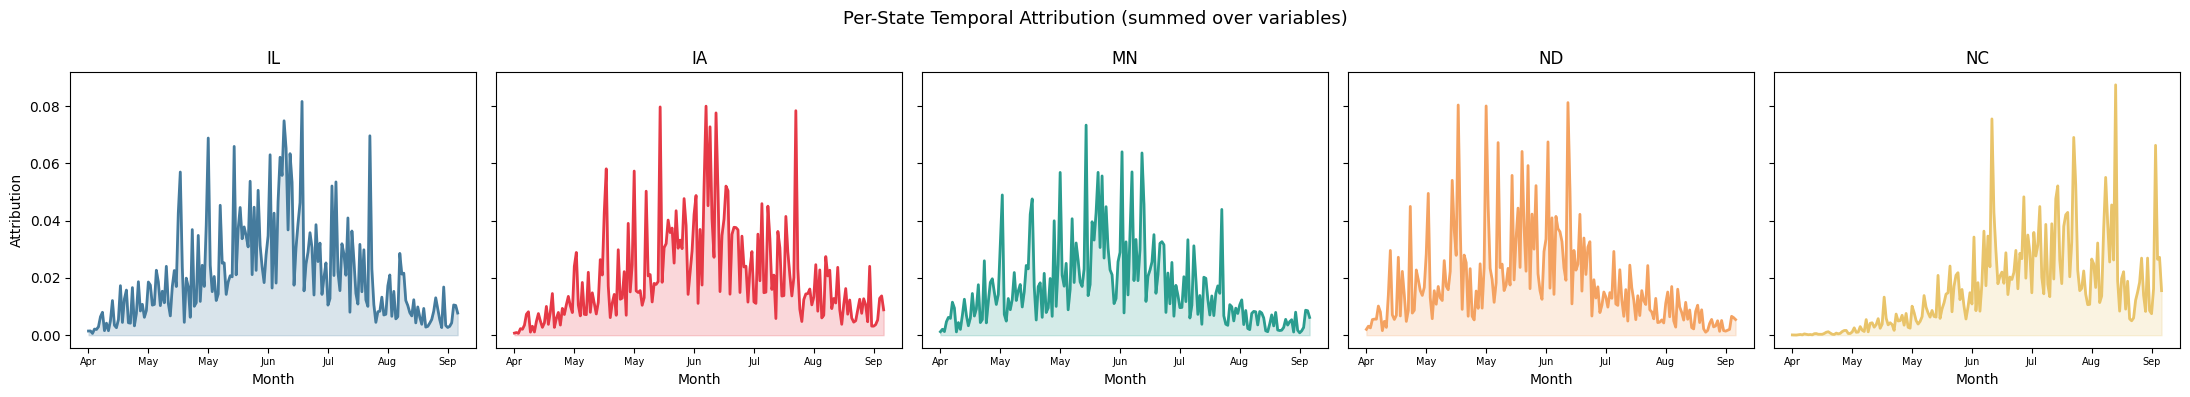

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# EXPL 12 — Per-State Temporal Attribution  (FIXED)
# ══════════════════════════════════════════════════════════════════════
# STATE_MAP in your notebook uses ANSI codes {'17':0,'19':1,...}
# but state records use abbreviations 'IL','IA','MN','ND','NC'
# This map bridges the two:
STATE_NAME_MAP = {'IL': 0, 'IA': 1, 'MN': 2, 'ND': 3, 'NC': 4}

def expl12_per_state_temporal_attribution():
    import datetime
    base  = datetime.date(2024, 4, 1)
    ticks = list(range(0, CFG['max_days'], 30))
    tick_labels = [(base + datetime.timedelta(days=d)).strftime('%b')
                   for d in ticks]

    fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)

    for ax, state_name in zip(axes, ['IL', 'IA', 'MN', 'ND', 'NC']):
        records = [r for r in test_ds.records if r['state'] == state_name]
        if not records:
            ax.set_title(f'{state_name}\n(no data)')
            continue

        # ── build tensors ─────────────────────────────────────────────
        st_   = torch.stack([r['short_term'] for r in records]).to(DEVICE)
        lt_   = ((torch.stack([r['long_term'] for r in records]).to(DEVICE)
                  - LT_MEAN) / LT_STD)

        # ← FIXED: use STATE_NAME_MAP, not STATE_MAP
        s_    = torch.tensor(
                    [STATE_NAME_MAP[state_name]] * len(records),
                    dtype=torch.long).to(DEVICE)

        c_    = torch.tensor(
                    [COUNTY_MAP.get(r['fips'], 0) for r in records],
                    dtype=torch.long).to(DEVICE)
        yf_   = torch.tensor(
                    [r['year_feat'].item() for r in records],
                    dtype=torch.float32).to(DEVICE)
        hist_ = torch.tensor(
                    [r['county_hist_yield'].item() for r in records],
                    dtype=torch.float32).to(DEVICE)
        prev_ = torch.tensor(
                    [r['prev_yield'].item() for r in records],
                    dtype=torch.float32).to(DEVICE)

        # ── normalize short-term and enable grad ──────────────────────
        st_n  = (st_ - ST_MEAN) / ST_STD
        st_n.requires_grad_(True)

        # ── forward + backward ────────────────────────────────────────
        model.eval()
        model.zero_grad()
        out = model(st_n, lt_, s_, c_, yf_, hist_, prev_)
        out.sum().backward()

        # ── attribution: mean |grad × input| summed over variables ───
        attr = (np.abs((st_n.grad * st_n)
                       .detach().cpu().numpy())
                       .mean(0)          # mean over batch → (9, T)
                       .sum(0))          # sum over vars   → (T,)

        ax.plot(attr, color=state_colors[state_name], lw=2)
        ax.fill_between(range(len(attr)), attr,
                        alpha=0.2, color=state_colors[state_name])
        ax.set_xticks(ticks)
        ax.set_xticklabels(tick_labels, fontsize=7)
        ax.set_title(state_name)
        ax.set_xlabel('Month')

    axes[0].set_ylabel('Attribution')
    plt.suptitle('Per-State Temporal Attribution (summed over variables)',
                 fontsize=13)
    plt.tight_layout()
    plt.show()

expl12_per_state_temporal_attribution()

In [ ]:
import torch
import torch.nn as nn
import pandas as pd

def count_params(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

def count_modules(module, types):
    if not isinstance(types, tuple):
        types = (types,)
    return sum(1 for m in module.modules() if isinstance(m, types))

rows = []

# Top-level model
rows.append({
    "module": "GraphCrossFormerV35",
    "layers": len(list(model.children())),
    "params": count_params(model)
})

# Major submodules
major_names = [
    "season_mask",
    "patch_embed",
    "graph_former",
    "cross_attn",
    "encoder",
    "temporal_pool",
    "var_branch",
    "climate_mlp",
    "state_emb",
    "county_emb",
    "hist_proj",
    "prev_proj",
    "prev_gate",
    "cond_proj",
    "context_proj",
    "branch_fusion",
    "head",
]

for name in major_names:
    mod = getattr(model, name)
    if isinstance(mod, nn.ModuleList):
        layer_count = len(mod)
    else:
        layer_count = len(list(mod.children())) if len(list(mod.children())) > 0 else 1
    rows.append({
        "module": name,
        "layers": layer_count,
        "params": count_params(mod)
    })

# Internal layer breakdown for encoder
rows.append({
    "module": "encoder_total",
    "layers": len(model.encoder),
    "params": count_params(model.encoder)
})

# Build table
df = pd.DataFrame(rows)

# Nice formatting
df["params"] = df["params"].astype(int)
df["layers"] = df["layers"].astype(int)

print(df.to_string(index=False))

# Optional summary
total_params = count_params(model)
trainable_params = total_params
print("\nTotal trainable parameters:", f"{total_params:,}")
print("Number of encoder layers:", len(model.encoder))
print("Number of states:", len(STATE_MAP))
print("Number of counties:", N_COUNTIES)
print("HRRR variables:", len(HRRR_VARS))

             module  layers  params
GraphCrossFormerV35      17 1154276
        season_mask       1      10
        patch_embed       1    8192
       graph_former       3  115072
         cross_attn       3   66304
            encoder       3  547968
      temporal_pool       3   91392
         var_branch       4   90240
        climate_mlp       1  116352
          state_emb       1     160
         county_emb       1   13056
          hist_proj       3      49
          prev_proj       3      49
          prev_gate       1       5
          cond_proj       3   38610
       context_proj       3   25344
      branch_fusion       4   33152
               head       4    8321
      encoder_total       3  547968

Total trainable parameters: 1,154,276
Number of encoder layers: 3
Number of states: 5
Number of counties: 408
HRRR variables: 9


In [ ]:
summary = df.copy()
summary["params"] = summary["params"].map(lambda x: f"{x:,}")
print(summary.to_markdown(index=False))

| module              |   layers | params    |
|:--------------------|---------:|:----------|
| GraphCrossFormerV35 |       17 | 1,154,276 |
| season_mask         |        1 | 10        |
| patch_embed         |        1 | 8,192     |
| graph_former        |        3 | 115,072   |
| cross_attn          |        3 | 66,304    |
| encoder             |        3 | 547,968   |
| temporal_pool       |        3 | 91,392    |
| var_branch          |        4 | 90,240    |
| climate_mlp         |        1 | 116,352   |
| state_emb           |        1 | 160       |
| county_emb          |        1 | 13,056    |
| hist_proj           |        3 | 49        |
| prev_proj           |        3 | 49        |
| prev_gate           |        1 | 5         |
| cond_proj           |        3 | 38,610    |
| context_proj        |        3 | 25,344    |
| branch_fusion       |        4 | 33,152    |
| head                |        4 | 8,321     |
| encoder_total       |        3 | 547,968   |
